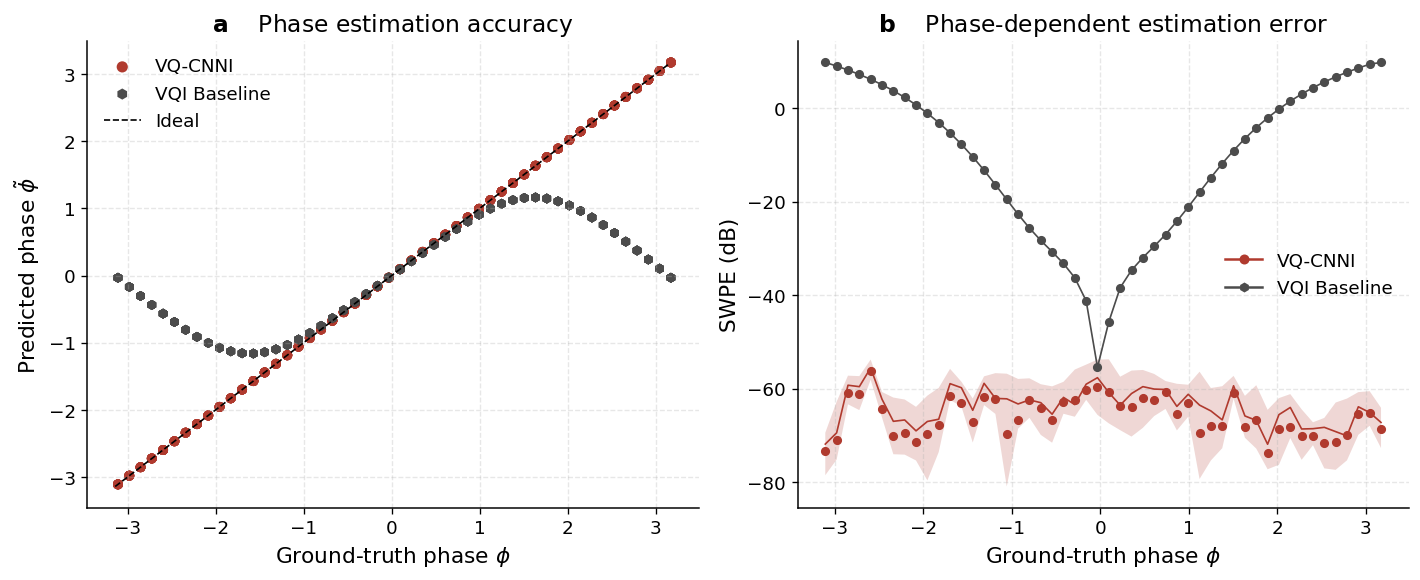


===== Overall mean SWPE (dB) across all phases and runs =====
1. VQ-CNNI             mean = -65.89 dB  [25%: -70.94, 75%: -58.98] dB
2. VQI Baseline        mean = -11.24 dB  [25%: -25.67, 75%: 4.36] dB


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.lines import Line2D

# =====================================================
# Nature Communications style (optimized)
# =====================================================
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 1.5,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "figure.dpi": 120
})

# ===============================
# parameters
# ===============================
n_qubits = 8
n_enc, n_dec = 1, 1
phi_train_samples = 100
n_phi = 50
phi_trues = np.linspace(-np.pi + np.pi/phi_train_samples,
                        np.pi + np.pi/phi_train_samples, n_phi)

phi_std = 0.7
scope = [-np.pi, np.pi]

vqi_path = f"VQI/{n_qubits}/vqc_{n_enc}_{n_dec}_{phi_std}"
vqcnni_base_path = f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}"

paths = {
    "VQI": vqi_path,
    "softsign": f"{vqcnni_base_path}/softsign",
}

markers = {
    "VQI": "h",
    "softsign": "o",
}

linestyles = {
    "VQI": "-",
    "softsign": "-",
}

colors = {
    "VQI": "#4C4C4C",
    "softsign": "#B03A2E",
}

label_map = {
    "VQI": "VQI Baseline",
    "softsign": "VQ-CNNI",
}

# ===============================
# load data (runs × n_phi)
# ===============================
phi_preds_all = {}

for name, path in paths.items():
    file = os.path.join(path, "phi_preds_shots20.npy")
    if os.path.exists(file):
        phi_preds_all[name] = np.load(file)
    else:
        raise FileNotFoundError(f"Required data file not found: {file}")

# ===============================
# compute SWPE
# ===============================
def compute_swpe_db(phi_pred, phi_true):
    diff = np.angle(np.exp(1j * (phi_pred - phi_true)))
    swpe = diff**2 + 1e-12
    return 10 * np.log10(swpe)

SWPE_all = {}
mean_swpe_overall = {}
median_swpe = {}
percentile_25 = {}
percentile_75 = {}
mean_swpe_phi = {}

for name, phi_preds_array in phi_preds_all.items():
    runs, n_phi_vals = phi_preds_array.shape
    swpe_array = np.zeros((runs, n_phi_vals))
    for r in range(runs):
        swpe_array[r, :] = compute_swpe_db(phi_preds_array[r, :], phi_trues)
    SWPE_all[name] = swpe_array

    mean_swpe_overall[name] = np.mean(swpe_array)
    median_swpe[name] = np.median(swpe_array, axis=0)
    percentile_25[name] = np.percentile(swpe_array, 25, axis=0)
    percentile_75[name] = np.percentile(swpe_array, 75, axis=0)
    mean_swpe_phi[name] = np.mean(swpe_array, axis=0)

sorted_models = sorted(mean_swpe_overall, key=lambda x: mean_swpe_overall[x])

# =====================================================
# FIGURE
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --------------------------
# (a) Predicted vs True φ
# --------------------------
ax = axes[0]
legend_handles_a = []

for name in sorted_models:
    label = label_map.get(name, name)
    phi_preds_array = phi_preds_all[name]
    runs, _ = phi_preds_array.shape

    for r in range(runs):
        ax.scatter(phi_trues, phi_preds_array[r, :],
                   label=label if r == 0 else "",
                   marker=markers[name],
                   color=colors[name],
                   s=35,
                   alpha=0.5,
                   edgecolors='none')

    # 不透明的代理散点用于图例
    proxy = ax.scatter([], [], marker=markers[name], color=colors[name],
                       s=45, alpha=1.0, edgecolors='none')
    legend_handles_a.append(proxy)

# 理想线
lims = [scope[0], scope[1]]
ax.plot(lims, lims, 'k--', linewidth=1.0, label="Ideal")
legend_handles_a.append(Line2D([0], [0], color='k', linestyle='--', linewidth=1.0))

ax.set_xlabel(r"Ground-truth phase $\phi$")
ax.set_ylabel(r"Predicted phase $\tilde{\phi}$")
ax.set_title(r"$\mathbf{a}\quad$ Phase estimation accuracy")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(handles=legend_handles_a,
          labels=[label_map[n] for n in sorted_models] + ["Ideal"],
          frameon=False, fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --------------------------
# (b) SWPE vs φ
# --------------------------
ax = axes[1]
legend_handles_b = []

for name in sorted_models:
    label = label_map.get(name, name)
    phi = phi_trues
    med = median_swpe[name]
    mean_vals = mean_swpe_phi[name]
    p25 = percentile_25[name]
    p75 = percentile_75[name]

    # 中位数线（实线）
    ax.plot(phi, med, color=colors[name], linestyle=linestyles[name],
            linewidth=1.0, label=label)
    # 均值点
    ax.scatter(phi, mean_vals, color=colors[name], s=20, zorder=5)
    # 25%-75% 阴影带
    ax.fill_between(phi, p25, p75, color=colors[name], alpha=0.2, edgecolor='none')

    # 自定义图例 handle：线 + 点
    custom_handle = Line2D([0], [0], color=colors[name], linestyle=linestyles[name],
                           linewidth=1.5, marker=markers[name], markersize=6,
                           markerfacecolor=colors[name], markeredgecolor='none')
    legend_handles_b.append(custom_handle)

ax.set_xlabel(r"Ground-truth phase $\phi$")
ax.set_ylabel(r"SWPE (dB)")
ax.set_title(r"$\mathbf{b}\quad$ Phase-dependent estimation error")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(handles=legend_handles_b, labels=[label_map[n] for n in sorted_models],
          frameon=False, fontsize=11, ncol=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("phase_combined_final.pdf", bbox_inches='tight', dpi=600)
plt.savefig("phase_combined_final.png", bbox_inches='tight', dpi=300)
plt.show()

# ===============================
# print statistics
# ===============================
print("\n===== Overall mean SWPE (dB) across all phases and runs =====")
for i, name in enumerate(sorted_models):
    label = label_map.get(name, name)
    mean_val = mean_swpe_overall[name]
    all_swpe = SWPE_all[name].flatten()
    p25_all = np.percentile(all_swpe, 25)
    p75_all = np.percentile(all_swpe, 75)
    print(f"{i+1}. {label:18s}  mean = {mean_val:.2f} dB  [25%: {p25_all:.2f}, 75%: {p75_all:.2f}] dB")

C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_20248\199555915.py:213: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_g.boxplot(box_data, labels=box_labels, showfliers=False,


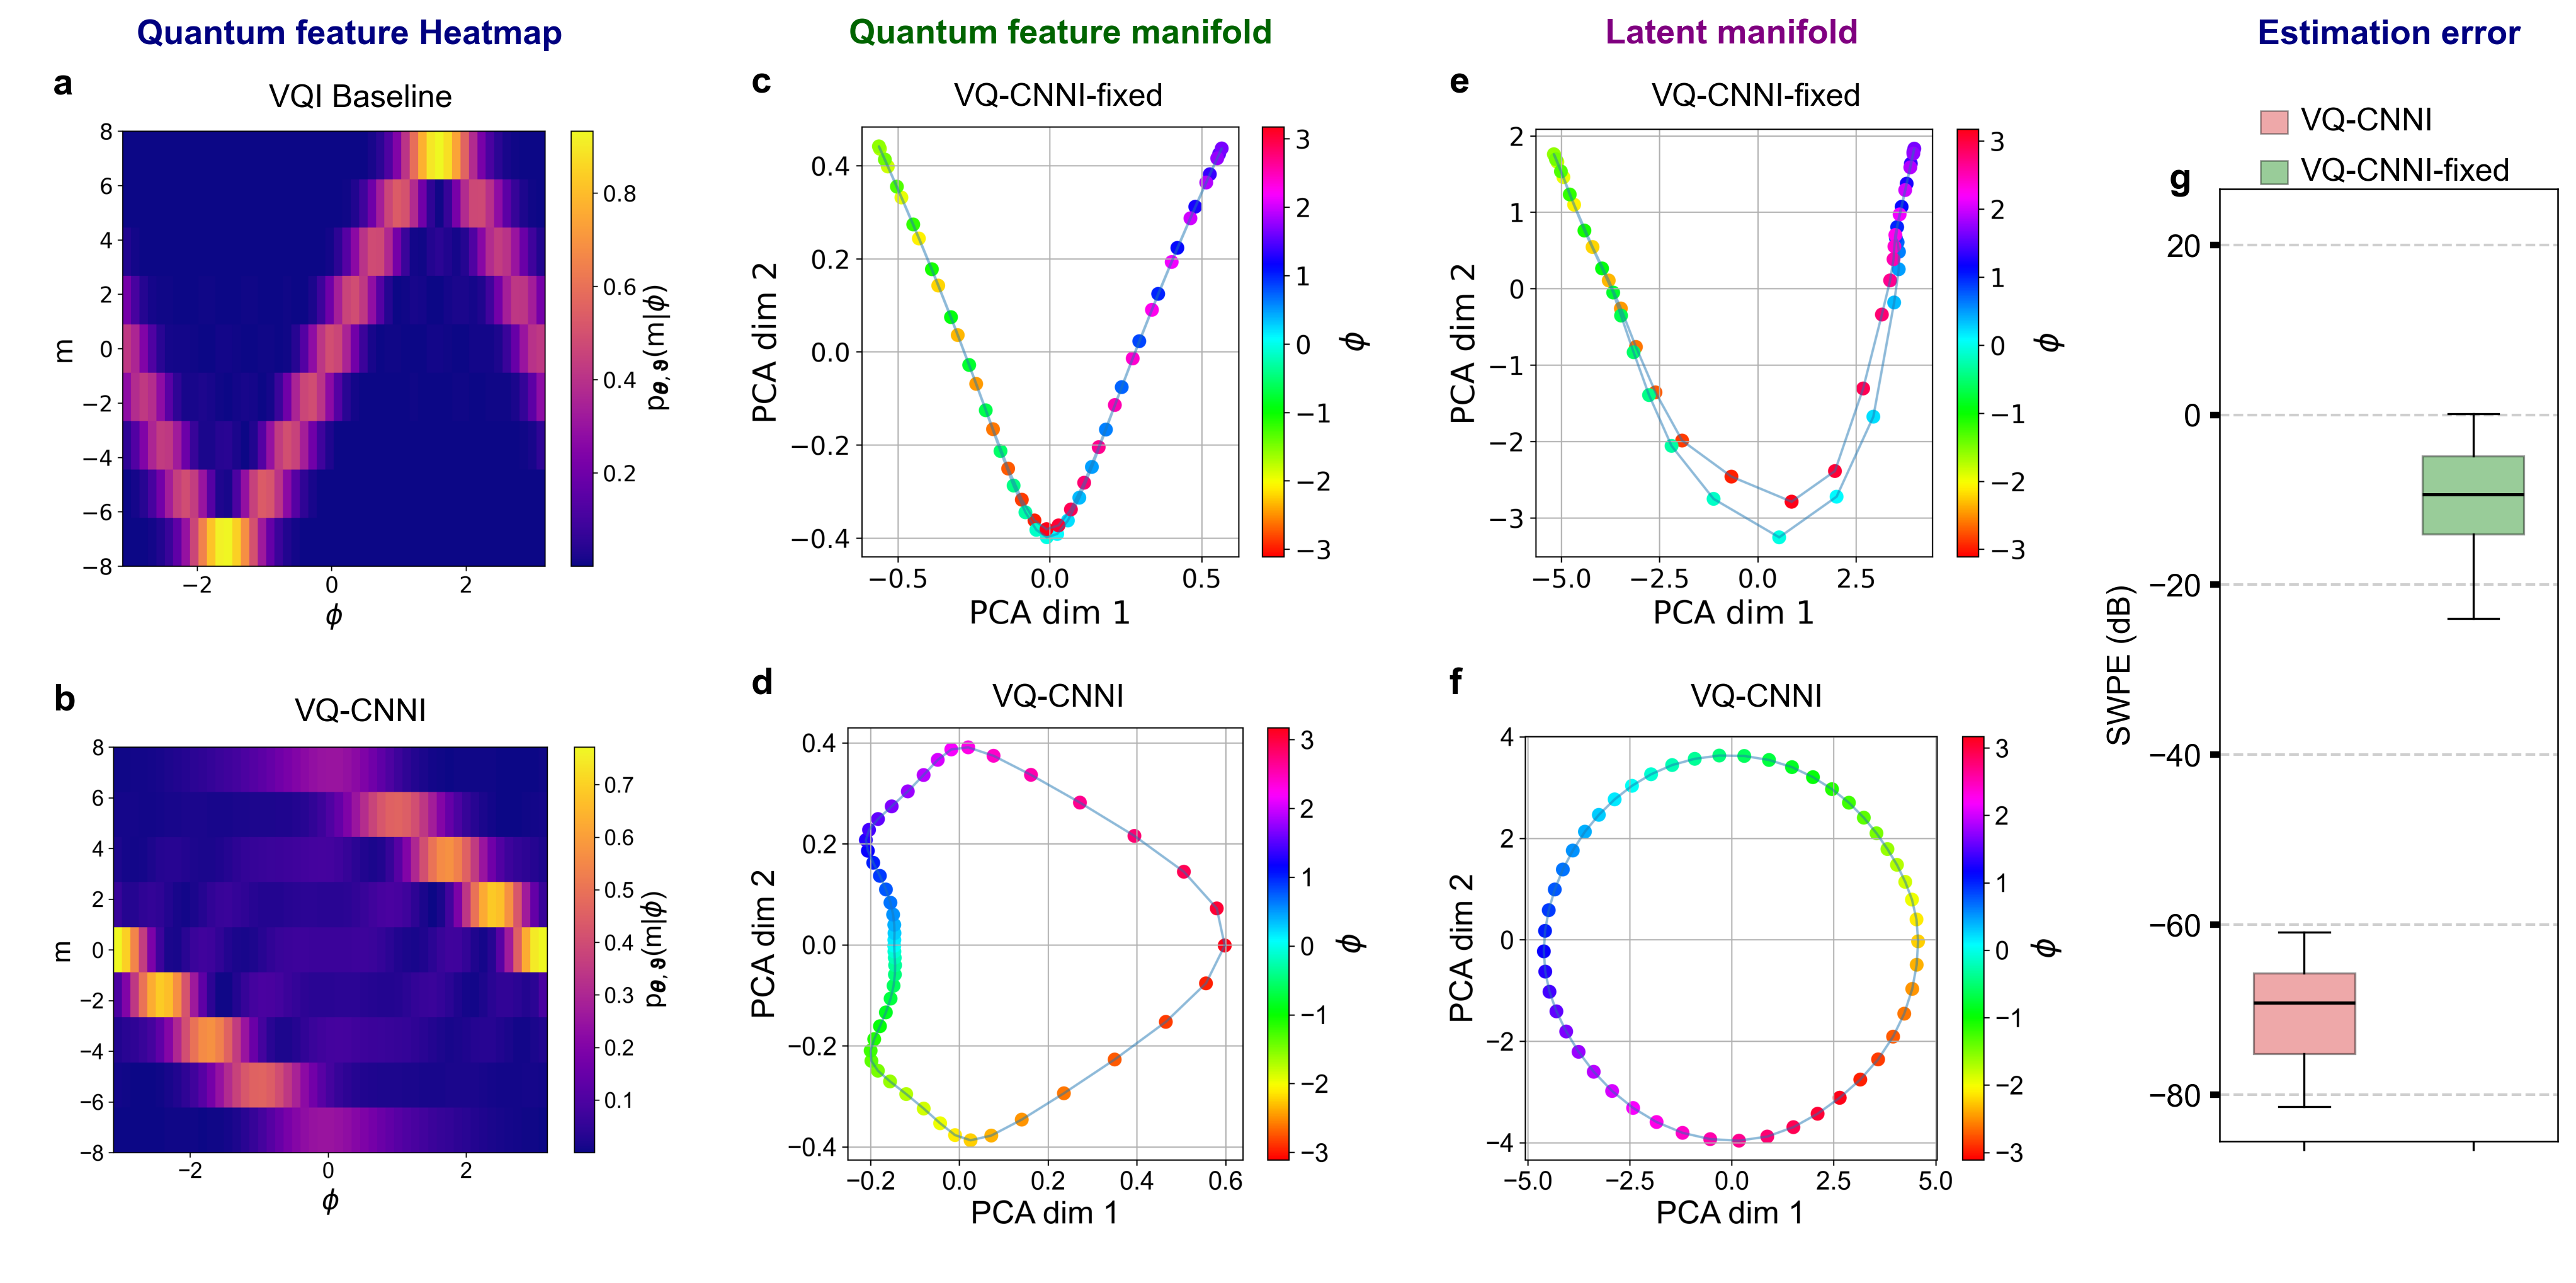

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import numpy as np
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

# ============================================================
# Nature Communications style (与参考代码一致)
# ============================================================

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 0.6
})

# ===============================
# parameters
# ===============================
n_qubits = 8
n_enc, n_dec = 1, 1
phi_trues = np.linspace(-np.pi + np.pi/100, np.pi + np.pi/100, 50)

vqcnni_base_path = f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}"
vqcnni_fixedParam = f"VQ-CNNI_fixedParam/{n_qubits}/vqc_{n_enc}_{n_dec}"

# ===============================
# 模型路径
# ===============================
paths = {
    "Softsign": f"{vqcnni_base_path}/softsign",
    "Softsign-BMSE": f"{vqcnni_fixedParam}/softsign",
}

label_map = {
    "Softsign": "VQ-CNNI",
    "Softsign-BMSE": "VQ-CNNI-fixed",
}

colors = {
    "Softsign": "#d62728",      # 红色
    "Softsign-BMSE": "green",   # 绿色
}

# ===============================
# 加载数据（用于SWPE计算）
# ===============================
phi_preds = {}

for name, path in paths.items():
    file = os.path.join(path, "phi_preds.npy")
    if os.path.exists(file):
        phi_preds[name] = np.load(file)
    else:
        print(f"Warning: {file} not found")

# ===============================
# wrapped phase error
# ===============================
def compute_swpe_db(phi_pred, phi_true):
    diff = np.angle(np.exp(1j*(phi_pred - phi_true)))
    swpe = diff**2 + 1e-12
    return 10*np.log10(swpe)

SWPE = {}
mean_swpe = {}

for name in phi_preds:
    SWPE[name] = compute_swpe_db(phi_preds[name], phi_trues)
    mean_swpe[name] = np.mean(SWPE[name])

# 按性能排序
sorted_models = sorted(mean_swpe, key=lambda x: mean_swpe[x])

# ============================================================
# Figure layout: 精细控制最后一列的间距（不影响前三列之间的间距）
# ============================================================

fig = plt.figure(figsize=(14, 7))

# 先分成两大块：前三列 + 最后一列
gs_main = GridSpec(
    1, 2,
    width_ratios=[4.0, 0.65],  # 前三列总宽度 : 最后一列宽度
    wspace=0.1,               # 这个间距控制两大部分之间的距离（最后一列左侧的间距）
    top=0.95, 
    bottom=0.05, 
    left=0.02, 
    right=0.98
)

# 前三列再细分为三列（2行×3列）
gs_left = GridSpecFromSubplotSpec(
    2, 3,
    subplot_spec=gs_main[0, 0],
    wspace=0.02,   # 前三列之间的水平间距（保持紧凑）
    hspace=0.02,   # 垂直间距
    width_ratios=[1.0, 1.0, 1.0]
)

# 最后一列作为整体（2行×1列）
gs_right = GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=gs_main[0, 1],
    hspace=0.02
)

# ============================================================
# Column 1: Probability heatmaps (a, b)
# ============================================================

# a: VQI baseline heatmap (第一行第一列)
ax_a = fig.add_subplot(gs_left[0, 0])
vqi_heatmap_path = os.path.join(paths["Softsign-BMSE"], "figs", "Quantum_feature_heatmap.png")
if os.path.exists(vqi_heatmap_path):
    ax_a.imshow(mpimg.imread(vqi_heatmap_path))
else:
    ax_a.text(0.5, 0.5, "Heatmap not found", ha='center')
ax_a.set_title('VQI Baseline', fontsize=12, y=0.95)
ax_a.axis('off')
ax_a.text(0.05, 1.0, 'a', transform=ax_a.transAxes, fontsize=14, fontweight='bold')

# b: Joint optimized heatmap (第二行第一列)
ax_b = fig.add_subplot(gs_left[1, 0])
joint_heatmap_path = os.path.join(paths["Softsign"], "figs", "Quantum_feature_heatmap.png")
if os.path.exists(joint_heatmap_path):
    ax_b.imshow(mpimg.imread(joint_heatmap_path))
else:
    ax_b.text(0.5, 0.5, "Heatmap not found", ha='center')
ax_b.set_title('VQ-CNNI', fontsize=12, y=0.95)
ax_b.axis('off')
ax_b.text(0.05, 1.0, 'b', transform=ax_b.transAxes, fontsize=14, fontweight='bold')

# ============================================================
# Column 2: Quantum feature manifolds (c, d)
# ============================================================

# c: Baseline quantum manifold (第一行第二列)
ax_c = fig.add_subplot(gs_left[0, 1])
baseline_embedding_path = os.path.join(paths["Softsign-BMSE"], "figs", "feature_embedding.png")
if os.path.exists(baseline_embedding_path):
    ax_c.imshow(mpimg.imread(baseline_embedding_path))
else:
    ax_c.text(0.5, 0.5, "Not found", ha='center')
ax_c.set_title('VQ-CNNI-fixed', fontsize=12, y=0.95)
ax_c.axis('off')
ax_c.text(0.05, 1.0, 'c', transform=ax_c.transAxes, fontsize=14, fontweight='bold')

# d: Joint quantum manifold (第二行第二列)
ax_d = fig.add_subplot(gs_left[1, 1])
joint_embedding_path = os.path.join(paths["Softsign"], "figs", "feature_embedding.png")
if os.path.exists(joint_embedding_path):
    ax_d.imshow(mpimg.imread(joint_embedding_path))
else:
    ax_d.text(0.5, 0.5, "Not found", ha='center')
ax_d.set_title('VQ-CNNI', fontsize=12, y=0.95)
ax_d.axis('off')
ax_d.text(0.05, 1.0, 'd', transform=ax_d.transAxes, fontsize=14, fontweight='bold')

# ============================================================
# Column 3: Latent manifolds (e, f)
# ============================================================

# e: Baseline latent manifold (第一行第三列)
ax_e = fig.add_subplot(gs_left[0, 2])
baseline_latent_path = os.path.join(paths["Softsign-BMSE"], "figs", "fig5_latent_manifold.png")
if os.path.exists(baseline_latent_path):
    ax_e.imshow(mpimg.imread(baseline_latent_path))
else:
    ax_e.text(0.5, 0.5, "Not found", ha='center')
ax_e.set_title('VQ-CNNI-fixed', fontsize=12, y=0.95)
ax_e.axis('off')
ax_e.text(0.05, 1.0, 'e', transform=ax_e.transAxes, fontsize=14, fontweight='bold')

# f: Joint latent manifold (第二行第三列)
ax_f = fig.add_subplot(gs_left[1, 2])
joint_latent_path = os.path.join(paths["Softsign"], "figs", "fig5_latent_manifold.png")
if os.path.exists(joint_latent_path):
    ax_f.imshow(mpimg.imread(joint_latent_path))
else:
    ax_f.text(0.5, 0.5, "Not found", ha='center')
ax_f.set_title('VQ-CNNI', fontsize=12, y=0.95)
ax_f.axis('off')
ax_f.text(0.05, 1.0, 'f', transform=ax_f.transAxes, fontsize=14, fontweight='bold')

# ============================================================
# Column 4: SWPE Boxplot (g) - spanning both rows
# ============================================================

# 最后一列的子图（占据两行）
ax_g = fig.add_subplot(gs_right[:, 0])
ax_g.tick_params(axis='y', width=2.5, which='major')
ax_g.tick_params(axis='y', labelsize=12, width=2.5)

# 设置子图位置偏移：从底部开始，占80%高度，向上对齐
box = ax_g.get_position()
ax_g.set_position([box.x0, box.y0+0.1, box.width, box.height * 0.8])

# 准备箱线图数据（按性能排序）
box_data = [SWPE[name] for name in sorted_models]
box_labels = [''] * len(sorted_models)
box_colors = [colors[name] for name in sorted_models]

# 绘制箱线图
bp = ax_g.boxplot(box_data, labels=box_labels, showfliers=False,
                  patch_artist=True, widths=0.6, whis=(5, 95))

# 设置不同颜色
for patch, c in zip(bp['boxes'], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.4)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.8)

# 设置中位数线颜色
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(1.2)

# 设置须线颜色
for whisker in bp['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(0.8)
for cap in bp['caps']:
    cap.set_color('black')
    cap.set_linewidth(0.8)

ax_g.set_ylabel(r'SWPE (dB)', fontsize=12)
ax_g.set_xlabel(r'', fontsize=12)
ax_g.grid(True, linestyle='--', alpha=0.6, axis='y', linewidth=1.0)

# 设置y轴范围，留出上方空间给标签
y_min, y_max = ax_g.get_ylim()
ax_g.set_ylim(y_min, y_max + (y_max - y_min) * 0.25)

# 添加子图标签 g
ax_g.text(-0.15, 1.0, 'g', transform=ax_g.transAxes, fontsize=14, fontweight='bold')

# 获取更新后的子图位置
box = ax_g.get_position()

# ============================================================
# 在子图g上方留出的20%空间中绘制图例标签
# ============================================================
ax_legend = fig.add_axes([box.x0, box.y0+0.1 + box.height * 0.8, box.width, box.height * 0.15])
ax_legend.axis('off')

# 绘制两个带颜色的小方框和对应的标签（垂直排列）
legend_items = [
    ("#d62728", "VQ-CNNI"),
    ("green", "VQ-CNNI-fixed")
]

# 垂直居中显示
num_items = len(legend_items)
spacing = 0.35
start_y = (1 + (num_items - 1) * spacing) / 2

for i, (color, label) in enumerate(legend_items):
    y_center = start_y - i * spacing + 0.2
    x_center = 0.2
    
    # 绘制彩色小方块
    rect = plt.Rectangle((x_center - 0.08, y_center - 0.08), 0.08, 0.16, 
                          facecolor=color, alpha=0.4, edgecolor='black', linewidth=0.6)
    ax_legend.add_patch(rect)
    
    # 绘制标签文字
    ax_legend.text(x_center + 0.04, y_center, label, fontsize=12, va='center', ha='left')

# ============================================================
# Column titles (使用子图位置计算)
# ============================================================

# 获取前三列各个子图的位置用于定位列标题
ax_a_pos = ax_a.get_position()
ax_c_pos = ax_c.get_position()
ax_e_pos = ax_e.get_position()

# 第一列标题位置（热图）- 基于ax_a和ax_b的中间
fig.text((ax_a_pos.x0 + ax_b.get_position().x0) / 2 + 0.125 , 0.98,
         r'Quantum feature Heatmap',
         ha='center', fontsize=13, fontweight='bold', color='navy')

# 第二列标题位置（量子流形）- 基于ax_c和ax_d的中间
fig.text((ax_c_pos.x0 + ax_d.get_position().x0) / 2 + 0.13, 0.98,
         'Quantum feature manifold',
         ha='center', fontsize=13, fontweight='bold', color='darkgreen')

# 第三列标题位置（潜在流形）- 基于ax_e和ax_f的中间
fig.text((ax_e_pos.x0 + ax_f.get_position().x0) / 2 + 0.12, 0.98,
         'Latent manifold',
         ha='center', fontsize=13, fontweight='bold', color='purple')

# 第四列标题位置（箱线图）
fig.text(box.x0 + box.width/2, 0.98,
         'Estimation error',
         ha='center', fontsize=13, fontweight='bold', color='navy')

# ============================================================
# Save
# ============================================================

plt.savefig('NC_style_composite_figure.pdf', bbox_inches='tight', dpi=600)
plt.savefig('NC_style_composite_figure.png', bbox_inches='tight', dpi=300, facecolor='white')

plt.show()


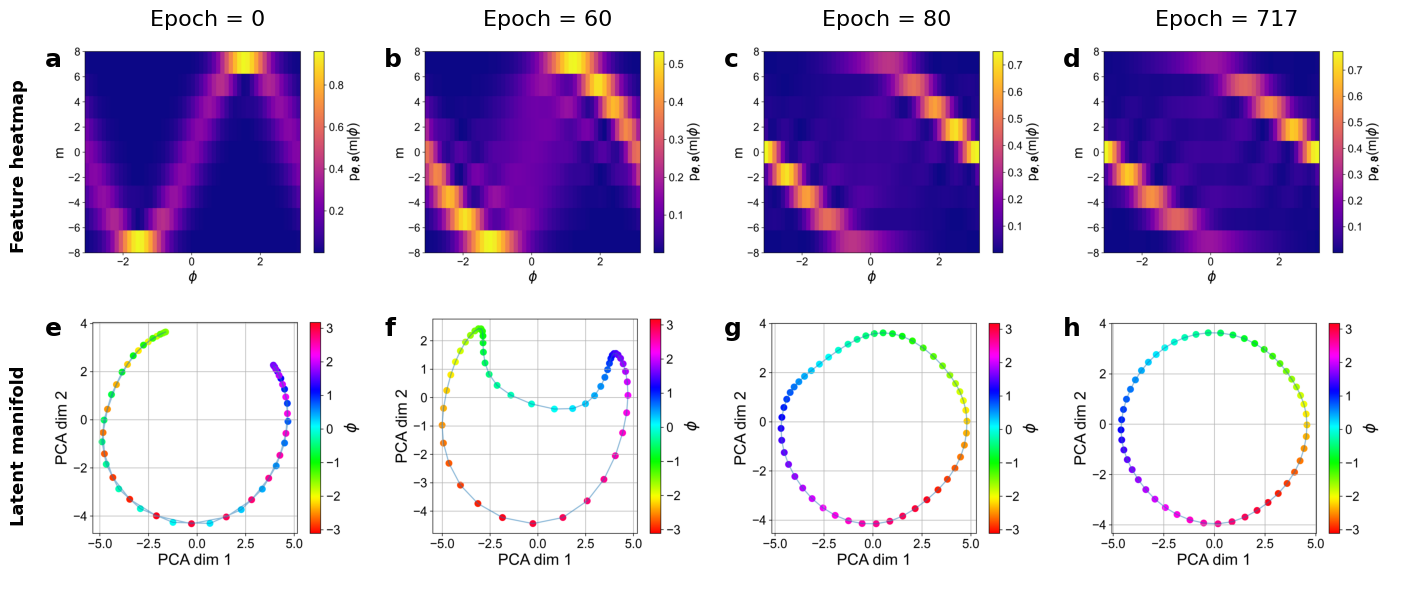

C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_20248\3201732638.py:214: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil_img = Image.fromarray(data, 'RGBA')
C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_20248\3201732638.py:230: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


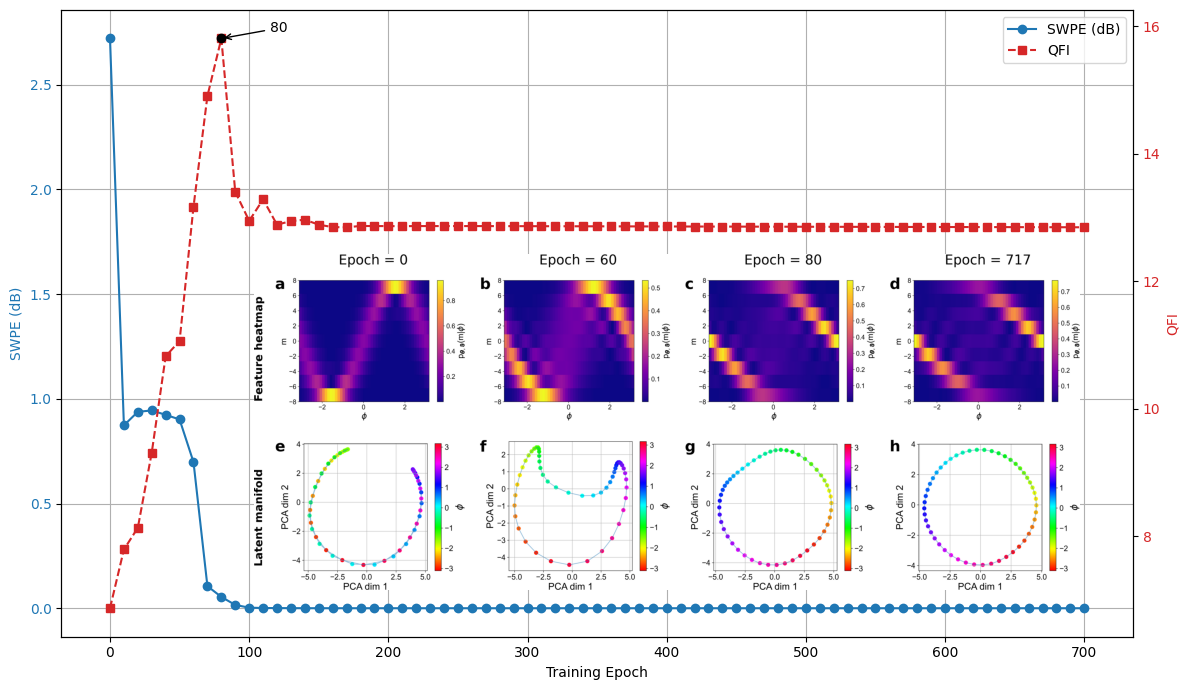

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import numpy as np
import string
# ===============================
# parameters
# ===============================
n_qubits = 8
n_enc, n_dec = 1, 1
phi_trues = np.linspace(-np.pi + np.pi/100, np.pi + np.pi/100, 50)
phi_std = 0.7

# ===============================
# 模型路径
# ===============================
paths = {
    "Epoch = 0": f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}/softsign/figs_init",
    "Epoch = 60": f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}/softsign/figs_epoch60",
    "Epoch = 80": f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}/softsign/figs_maxqfi",
    "Epoch = 717": f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}/softsign/figs"
}

model_names = list(paths.keys())
n_models = len(model_names)

# ===============================
# 创建 2 行：上 = embedding，下 = manifold
# ===============================

plt.rcdefaults()
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.right'] = True

fig, axes = plt.subplots(2, n_models, figsize=(3.5*n_models, 7))

labels = list(string.ascii_lowercase)  # (a), (b), ...

# ===============================
# 绘制
# ===============================
for i, (name, path) in enumerate(paths.items()):
    
    # ---------- Feature embedding ----------
    img_path1 = os.path.join(path, "Quantum_feature_heatmap.png")
    ax1 = axes[0, i]

    if os.path.exists(img_path1):
        img1 = mpimg.imread(img_path1)
        ax1.imshow(img1)
    else:
        ax1.text(0.5, 0.5, "Not found", ha='center')

    ax1.set_title(name, fontsize=16)
    ax1.axis('off')

    # 编号 (a)(b)(c)...
    ax1.text(0.02, 0.95, f"{labels[i]}",
             transform=ax1.transAxes,
             fontsize=18, fontweight='bold',
             va='top')

    # ---------- Latent manifold ----------  
    img_path2 = os.path.join(path, "fig5_latent_manifold.png")
    ax2 = axes[1, i]

    if os.path.exists(img_path2):
        img2 = mpimg.imread(img_path2)
        ax2.imshow(img2)
    else:
        ax2.text(0.5, 0.5, "Not found", ha='center')

    ax2.axis('off')

    # 编号继续 (d)(e)(f)...
    ax2.text(0.02, 0.95, f"{labels[i + n_models]}",
             transform=ax2.transAxes,
             fontsize=18, fontweight='bold',
             va='top')

# ===============================
# 行标签（论文很加分）
# ===============================
fig.text(0, 0.7, "Feature heatmap",
         va='center', rotation='vertical', fontsize=13, fontweight='bold')

fig.text(0, 0.3, "Latent manifold",
         va='center', rotation='vertical', fontsize=13, fontweight='bold')

# 移除 plt.tight_layout() 这一行

# 手动调整子图间距和边距
plt.subplots_adjust(
    left=0.02,      # 左侧留空间给行标签 (Feature heatmap / Latent manifold)
    right=0.99,     # 右侧边界最小化
    bottom=0.02,    # 底部留少量空间
    top=0.98,       # 顶部留少量空间
    wspace=0,       # 水平间距 = 0
    hspace=-0.3        # 垂直间距 = 0
)

plt.savefig("Epoch_heatmap_manifold.png", dpi=300)
plt.savefig(
    "Epoch_heatmap_manifold.pdf",
    bbox_inches='tight',
    dpi=600,
    format='pdf'
)
plt.show()


import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "figure.dpi": 150
})

def safe_load_npy(path, name):
    """
    NC/PRX级 safe loader
    不存在不会报错，而是返回 None
    """
    file = os.path.join(path, name)

    if os.path.exists(file):
        return np.load(file, allow_pickle=True)
    else:
        print(f"[Warning] Missing file: {file}")
        return None

path = f"VQ-CNNI/{8}/vqc_{1}_{1}/softsign"
test_mse_list = safe_load_npy(path, "test_mse_vs_epoch.npy")
qfi_list = safe_load_npy(path, "qfi_vs_epoch.npy")
epoch_list = safe_load_npy(path, "epoch_list.npy")

plt.rcdefaults()
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.right'] = True

best_pnt = 717//10
fig, ax1 = plt.subplots(figsize=(12,7))

# 左轴：SWPE（dB）
color1 = 'tab:blue'
ax1.set_xlabel("Training Epoch")
ax1.set_ylabel("SWPE (dB)", color=color1)
ax1.plot(epoch_list[:best_pnt], test_mse_list[:best_pnt], marker='o', color=color1, label="SWPE (dB)")
ax1.tick_params(axis='y', labelcolor=color1)

# 可选：让“越好越高”
# ax1.invert_yaxis()

# 右轴：QFI
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel("QFI", color=color2)
ax2.plot(epoch_list[:best_pnt], qfi_list[:best_pnt], marker='s', linestyle='--', color=color2, label="QFI")
ax2.tick_params(axis='y', labelcolor=color2)

# =========================
# ⭐ 找到首次最大QFI的位置
# =========================
qfi_array = np.array(qfi_list[:best_pnt])
epoch_array = np.array(epoch_list[:best_pnt])

max_qfi = np.max(qfi_array)
max_idx = np.where(qfi_array == max_qfi)[0][0]  # 第一次出现
max_epoch = epoch_array[max_idx]

# 对应点
x_point = max_epoch
y_point = max_qfi

# =========================
# ⭐ 标注（箭头 + 文本）
# =========================
ax2.scatter(x_point, y_point, color='black', zorder=5)

ax2.annotate(
    f"{max_epoch}",
    xy=(x_point, y_point),
    xytext=(x_point + (epoch_array[-1]-epoch_array[0])*0.05, y_point + 0.1),
    arrowprops=dict(arrowstyle="->", color='black'),
    fontsize=10
)

# =========================
# 图例合并
# =========================
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')
ax1.grid(True)

try:
    from PIL import Image
    pil_img = Image.open("./Epoch_heatmap_manifold.png")
    # 转换为 RGBA 模式
    pil_img = pil_img.convert('RGBA')
    data = np.array(pil_img)
    # 将纯白色（R=255,G=255,B=255）的 alpha 设为 0，变为透明
    white_mask = (data[:,:,:3] == 255).all(axis=2)
    data[white_mask, 3] = 0
    pil_img = Image.fromarray(data, 'RGBA')
    # 获取非透明区域边界框
    bbox = pil_img.getbbox()
    if bbox:
        cropped = pil_img.crop(bbox)
        cropped_arr = np.array(cropped.convert('RGB'))
    else:
        cropped_arr = np.array(pil_img.convert('RGB'))

    ax_inset = fig.add_axes([0.2, 0.15, 0.72, 0.48])
    ax_inset.imshow(cropped_arr)
    ax_inset.axis('off')

except FileNotFoundError:
    print("Inset image not found, skipping.")

fig.tight_layout()
plt.savefig(f"./swpe_qfi_combined.png", dpi=300)
plt.savefig(f"./swpe_qfi_combined.pdf", dpi=600, bbox_inches='tight')
plt.show()


C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_20248\3393975601.py:264: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


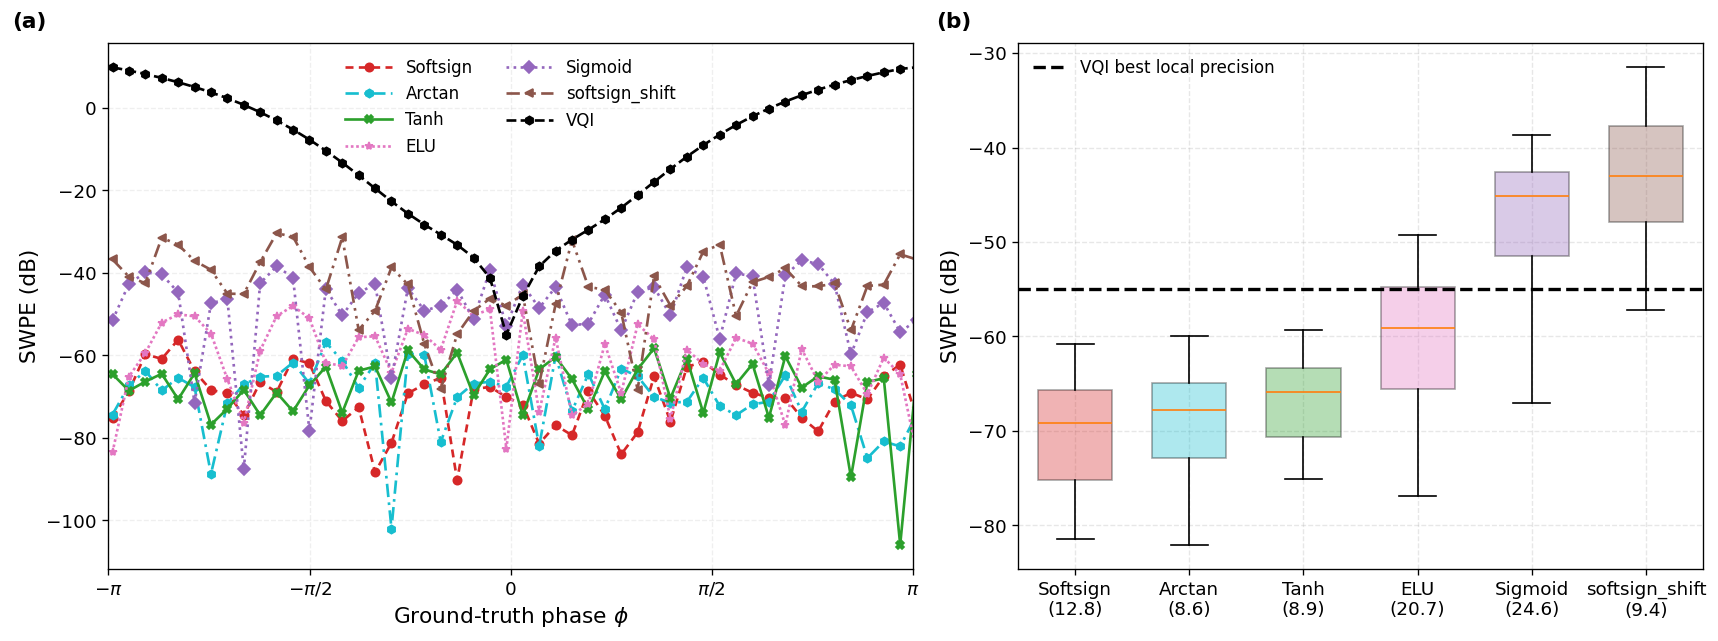


===== Average SWPE Ranking =====
1. Softsign             -70.62 dB
2. Arctan               -69.83 dB
3. Tanh                 -67.78 dB
4. ELU                  -61.26 dB
5. Sigmoid              -48.61 dB
6. softsign_shift       -43.70 dB
7. VQI                  -11.23 dB


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.interpolate import make_interp_spline

# =====================================================
# NC-style: Fig.2 (a) + (b)
# (a) ALL-7 smooth SWPE curves (optimized visual hierarchy)
# (b) Boxplot + VQI baseline
# =====================================================
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 1.6,
    "figure.dpi": 120
})


# =====================================================
# parameters
# =====================================================

n_qubits = 8
n_enc, n_dec = 1, 1

phi_train_samples = 100
n_phi = 50

phi_trues = np.linspace(
    -np.pi + np.pi / phi_train_samples,
    np.pi + np.pi / phi_train_samples,
    n_phi
)

phi_std = 0.7

# =====================================================
# visual hierarchy for Fig (a)
# =====================================================

vqi_path = f"VQI/{n_qubits}/vqc_{n_enc}_{n_dec}_{phi_std}"
vqcnni_base_path = f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}"

paths = {
    "VQI": vqi_path,
    "tanh": f"{vqcnni_base_path}/tanh",
    "sigmoid":  f"{vqcnni_base_path}/sigmoid",
    "softsign": f"{vqcnni_base_path}/softsign",
    "softsign_shift": f"{vqcnni_base_path}/softsign_shift",
    "elu":      f"{vqcnni_base_path}/elu",
    "arctan":   f"{vqcnni_base_path}/arctan",
}

markers = {
    "VQI": "h",
    "tanh": "X",
    "sigmoid": "D",
    "softsign": "o",
    "softsign_shift": "<",   # 对称设计
    "elu": "*",
    "arctan": "h"
}

linestyles = {
    "VQI": "--",
    "tanh": "-",
    "sigmoid": ":",
    "softsign": (0,(3,2)),
    "softsign_shift": (0,(5,2,1,2,1,2)),  # 更复杂 pattern
    "elu": (0,(1,1)),
    "arctan": (0,(5,2,1,2))
}

colors = {
    "VQI": "black",
    "softsign": "#d62728",
    "tanh": "#2ca02c",
    "sigmoid": "#9467bd",
    "softsign_shift": "#8c564b",
    "elu": "#e377c2",
    "arctan": "#17becf"
}

label_map = {
    "VQI": "VQI",
    "tanh": "Tanh",
    "sigmoid": "Sigmoid",
    "softsign": "Softsign",
    "softsign_shift": "softsign_shift",
    "elu": "ELU",
    "arctan": "Arctan"
}

# draw weak -> strong
plot_order = [
    "arctan",
    "elu",
    "sigmoid",
    "tanh",
    "softsign_shift",
    "VQI",
    "softsign",
]


# =====================================================
# load data
# =====================================================

phi_preds = {}

for name, path in paths.items():
    file = os.path.join(path, "phi_preds.npy")

    if os.path.exists(file):
        phi_preds[name] = np.load(file)
    else:
        print(f"Warning: {file} not found")
        
# ===============================
# wrapped phase error
# ===============================
def compute_swpe_db(phi_pred, phi_true):

    diff = np.angle(np.exp(1j*(phi_pred - phi_true)))
    swpe = diff**2 + 1e-12

    return 10*np.log10(swpe)


SWPE = {}
mean_swpe = {}
min_swpe = {}
max_swpe = {}

for name in phi_preds:

    SWPE[name] = compute_swpe_db(phi_preds[name], phi_trues)
    mean_swpe[name] = np.mean(SWPE[name])
    min_swpe[name] = np.min(SWPE[name])
    max_swpe[name] = np.max(SWPE[name])

# ===============================
# sort models by performance
# ===============================
sorted_models = sorted(mean_swpe, key=lambda x: mean_swpe[x])


# =====================================================
# create combined figure
# =====================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(14.5, 5.5),
    gridspec_kw={"width_ratios": [1.35, 1.15]}
)


ax1, ax2 = axes

for name in phi_preds:
    SWPE[name] = compute_swpe_db(phi_preds[name], phi_trues)
    mean_swpe[name] = np.mean(SWPE[name])

sorted_models = sorted(mean_swpe, key=lambda x: mean_swpe[x])

# =====================================================
# (a) ALL-7 smooth SWPE curves
# =====================================================

for name in sorted_models:
    y = SWPE[name]

    # faint original sampled points
    ax1.scatter(
        phi_trues,
        y,
        s=10,
        alpha=0.05,
        color=colors[name],
        zorder=1
    )

    ax1.plot(
        phi_trues,
        SWPE[name],
        label=label_map[name],
        marker=markers[name],
        linestyle=linestyles[name],
        color=colors[name],
        markersize=5
    )

ax1.set_xlabel(r"Ground-truth phase $\phi$")
ax1.set_ylabel(r"SWPE (dB)")
ax1.set_xlim(-np.pi, np.pi)
ax1.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax1.set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])

ax1.grid(
    True,
    linestyle="--",
    alpha=0.20
)

ax1.legend(
    frameon=False,
    ncol=2,
    loc="best",
    handlelength=2.8
)

ax1.text(
    -0.12,
    1.03,
    "(a)",
    transform=ax1.transAxes,
    fontsize=13,
    fontweight="bold"
)

# =====================================================
# (b) Boxplot + VQI baseline
# =====================================================

box_data = []
box_labels = []
box_colors = []

# ===============================
# QFI values (for x-axis labels)
# ===============================

qfi_values = {
    "softsign": 12.8,
    "arctan": 8.6,
    "tanh": 8.9,
    "elu": 20.7,
    "sigmoid": 24.6,
    "softsign_shift": 9.4,
    "VQI": 17.4
}

for name in sorted_models:
    if name != "VQI":
        box_data.append(SWPE[name])

        # 激活函数名称 + 下一行括号QFI
        box_labels.append(
            f"{label_map[name]}\n({qfi_values[name]})"
        )

        box_colors.append(colors[name])

# VQI optimal operating point baseline
center_idx = np.argmin(np.abs(phi_trues))
vqi_baseline = SWPE["VQI"][center_idx]

bp = ax2.boxplot(
    box_data,
    labels=box_labels,
    showfliers=False,
    patch_artist=True,
    widths=0.65,
    # whis=(0, 100),
    whis=(5, 95),              # 5%-95%分位数须
)

for patch, c in zip(bp["boxes"], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.35)

ax2.axhline(
    y=vqi_baseline,
    linestyle="--",
    linewidth=2.0,
    color="black",
    label="VQI best local precision"
)

ax2.set_ylabel(r"SWPE (dB)")

ax2.grid(
    True,
    linestyle="--",
    alpha=0.30
)

ax2.legend(
    frameon=False,
    loc="best"
)

ax2.tick_params(
    axis="x",
    rotation=0
)

ax2.text(
    -0.12,
    1.03,
    "(b)",
    transform=ax2.transAxes,
    fontsize=13,
    fontweight="bold"
)

# =====================================================
# save
# =====================================================

plt.tight_layout()

plt.savefig(
    "Fig2_main_NC_style_final.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Fig2_main_NC_style_final.png",
    bbox_inches="tight"
)

plt.show()

# =====================================================
# ranking print
# =====================================================

print("\n===== Average SWPE Ranking =====")

for i, name in enumerate(sorted_models):
    print(
        f"{i+1}. {label_map[name]:20s} "
        f"{mean_swpe[name]:.2f} dB"
    )

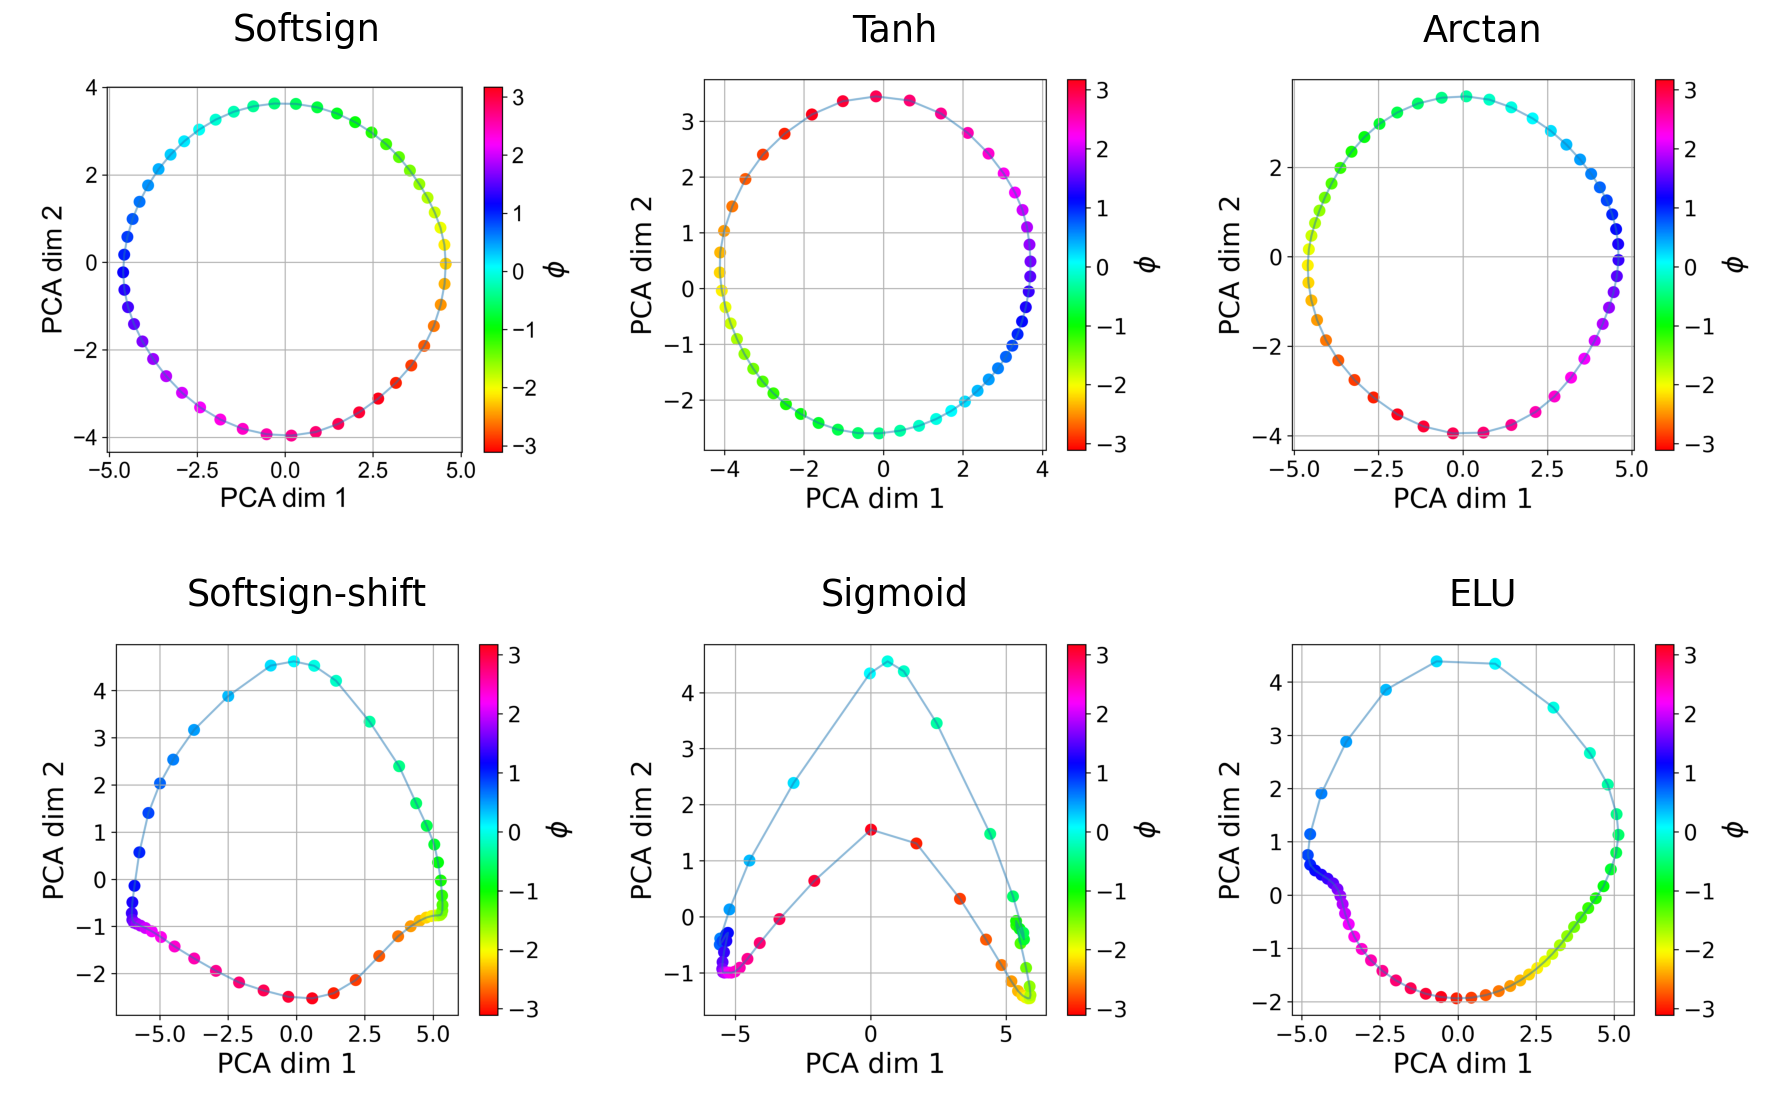

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# ===============================
# 模型路径（和你之前一致）
# ===============================
paths = {
    "Softsign": f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}/softsign/figs",
    "Tanh": f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}/tanh/figs",
    "Arctan": f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}/arctan/figs",
    "Softsign-shift": f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}/softsign_shift/figs",
    "Sigmoid": f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}/sigmoid/figs",
    "ELU": f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}/elu/figs",
}

# ===============================
# 创建子图布局
# ===============================
n_models = len(paths)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))

axes = axes.flatten()

# ===============================
# 读取并绘制
# ===============================
for i, (name, path) in enumerate(paths.items()):
    
    img_path = os.path.join(path, "fig5_latent_manifold.png")
    
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(name, fontsize=22)
    else:
        axes[i].text(0.5, 0.5, "Not found", ha='center')
        axes[i].set_title(name, fontsize=22)

    axes[i].axis('off')

# 删除多余子图
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# 关键：设置子图间距和边距
plt.subplots_adjust(
    left=-0.2,      # 左边距
    right=1.2,     # 右边距  
    bottom=-0.2,    # 底边距
    top=0.9,       # 顶边距
    wspace=-0.3,    # 子图之间的水平间距
    hspace=0.15     # 子图之间的垂直间距
)
# 保存时使用 bbox_inches='tight' 和 pad_inches=0
# plt.savefig("latent_manifold_all_models.png", dpi=600, bbox_inches='tight', pad_inches=0)
plt.savefig("latent_manifold_all_models.pdf", bbox_inches='tight', pad_inches=0, dpi=300, format='pdf')
plt.show()

C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_20248\1320240189.py:142: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=box_labels, showfliers=False,
C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_20248\1320240189.py:234: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


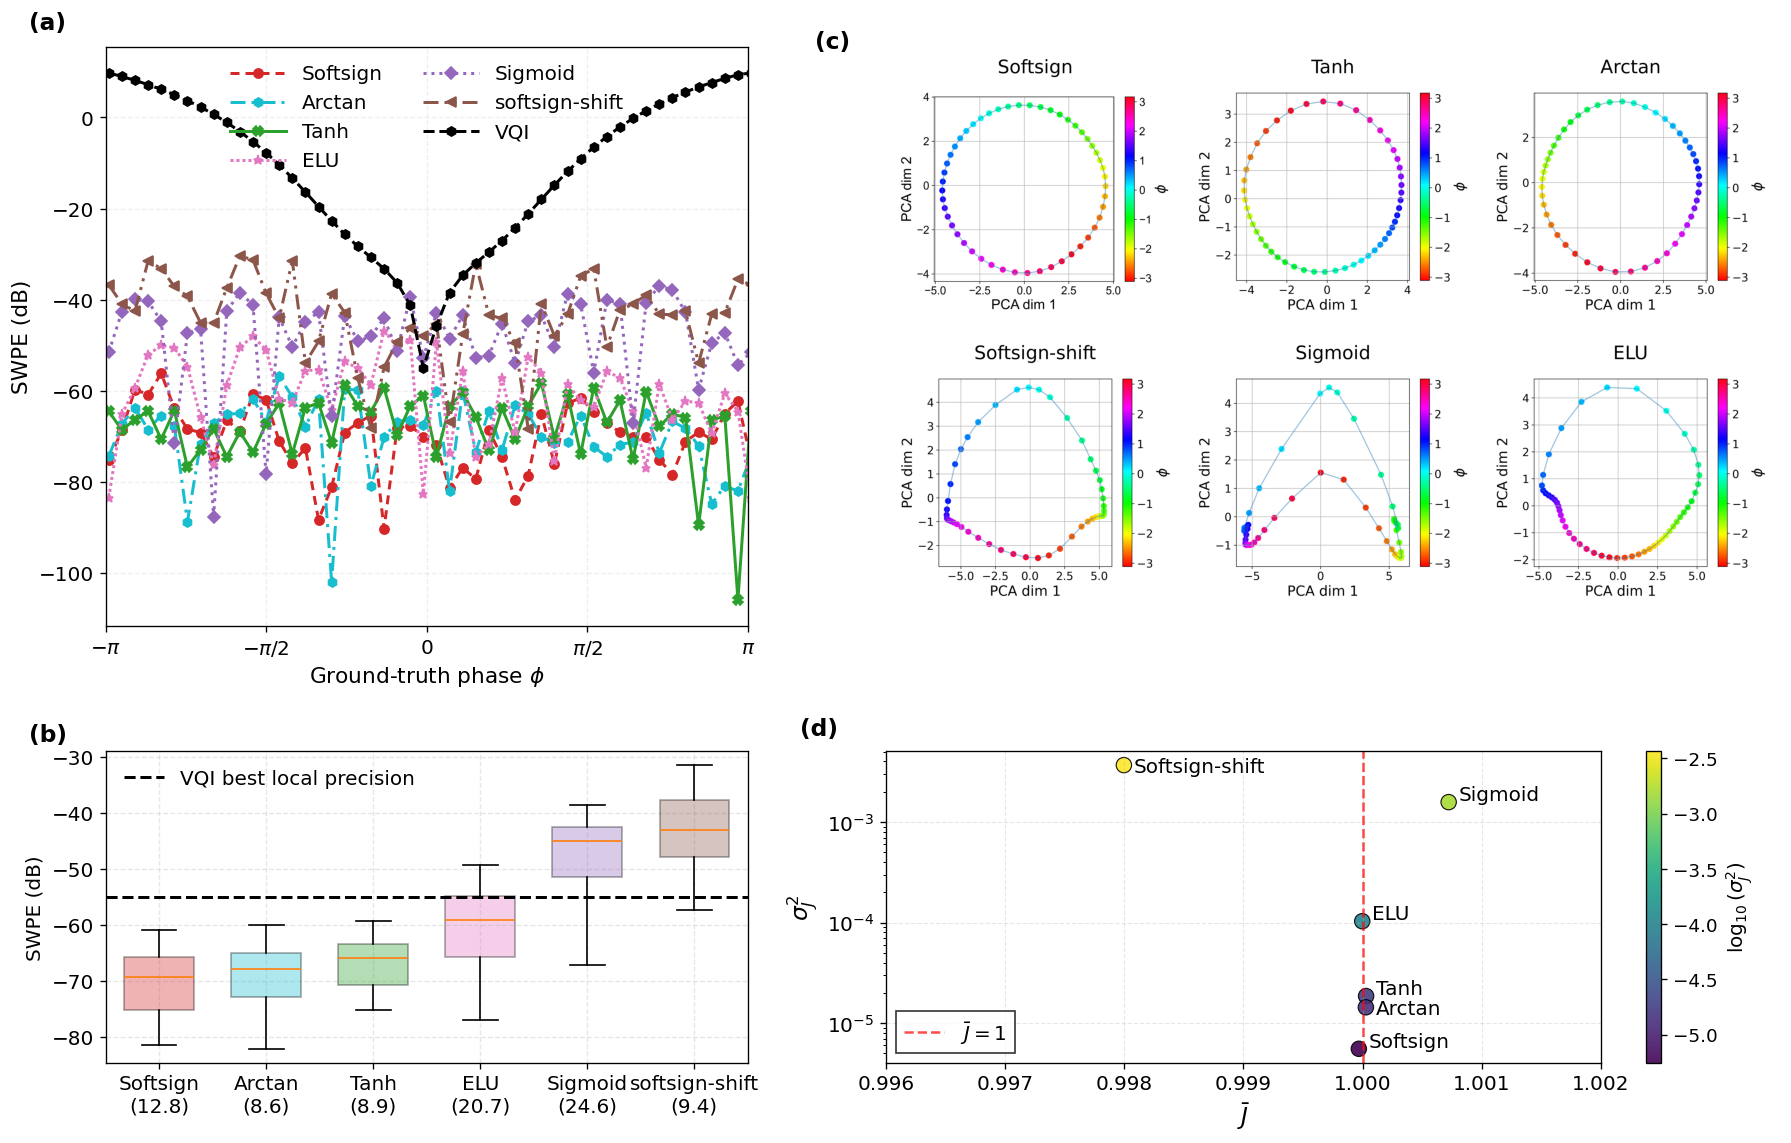

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import os
import fitz  # PyMuPDF

# =====================================================
# 全局配置
# =====================================================
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 1.6,
    "figure.dpi": 120
})

# =====================================================
# 参数定义
# =====================================================
n_qubits = 8
n_enc, n_dec = 1, 1
phi_train_samples = 100
n_phi = 50
phi_std = 0.7

phi_trues = np.linspace(-np.pi + np.pi/phi_train_samples, 
                        np.pi + np.pi/phi_train_samples, n_phi)

# =====================================================
# 模型配置
# =====================================================
vqi_path = f"VQI/{n_qubits}/vqc_{n_enc}_{n_dec}_{phi_std}"
vqcnni_base = f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}"

models = {
    "VQI": {"path": vqi_path, "label": "VQI", "color": "black", 
            "marker": "h", "linestyle": "--", "qfi": 17.4},
    "tanh": {"path": f"{vqcnni_base}/tanh", "label": "Tanh", "color": "#2ca02c",
             "marker": "X", "linestyle": "-", "qfi": 8.9},
    "sigmoid": {"path": f"{vqcnni_base}/sigmoid", "label": "Sigmoid", "color": "#9467bd",
                "marker": "D", "linestyle": ":", "qfi": 24.6},
    "softsign": {"path": f"{vqcnni_base}/softsign", "label": "Softsign", "color": "#d62728",
                 "marker": "o", "linestyle": (0, (3, 2)), "qfi": 12.8},
    "softsign-shift": {"path": f"{vqcnni_base}/softsign_shift", "label": "softsign-shift", 
                       "color": "#8c564b", "marker": "<", "linestyle": (0, (5, 2, 1, 2, 1, 2)), "qfi": 9.4},
    "elu": {"path": f"{vqcnni_base}/elu", "label": "ELU", "color": "#e377c2",
            "marker": "*", "linestyle": (0, (1, 1)), "qfi": 20.7},
    "arctan": {"path": f"{vqcnni_base}/arctan", "label": "Arctan", "color": "#17becf",
               "marker": "h", "linestyle": (0, (5, 2, 1, 2)), "qfi": 8.6}
}

# =====================================================
# Jacobian数据
# =====================================================
jacobian_data = {
    'tanh': {'mean': 1.0000294539239016, 'var': 1.8566152934941547e-05},
    'sigmoid': {'mean': 1.000722381941264, 'var': 0.0015767558672795307},
    'elu': {'mean': 0.9999968942878045, 'var': 0.00010310047034810306},
    'arctan': {'mean': 1.00002755806634, 'var': 1.4348247494348468e-05},
    'softsign': {'mean': 0.9999684924136879, 'var': 5.547654738055314e-06},
    'softsign-shift': {'mean': 0.9979963921744658, 'var': 0.003680973121346913}
}

# =====================================================
# 加载并计算SWPE
# =====================================================
def compute_swpe_db(phi_pred, phi_true):
    diff = np.angle(np.exp(1j * (phi_pred - phi_true)))
    return 10 * np.log10(diff**2 + 1e-12)

phi_preds = {}
swpe_data = {}

for name, cfg in models.items():
    file = os.path.join(cfg["path"], "phi_preds.npy")
    if os.path.exists(file):
        phi_preds[name] = np.load(file)
        swpe_data[name] = compute_swpe_db(phi_preds[name], phi_trues)
    else:
        print(f"Warning: {file} not found")

# 按性能排序
sorted_models = sorted([m for m in models.keys() if m in swpe_data], 
                       key=lambda x: np.mean(swpe_data[x]))

# =====================================================
# 创建图形 - a和c扩大，b和d减小
# =====================================================
# 布局方案：2x2网格，但调整高度和宽度比例
# 宽度比例：左列(a和b) : 右列(c和d) = 1 : 1.6  (让c更宽)
# 高度比例：上行(a和c) : 下行(b和d) = 1.4 : 0.6  (让a和c更高)
fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(2, 2, 
                      height_ratios=[1.3, 0.7],   # 上行高，下行矮
                      width_ratios=[1.15, 1.6],    # 右列宽，左列窄
                      hspace=0.28, wspace=0.18)

ax1 = fig.add_subplot(gs[0, 0])  # (a) SWPE curves - 扩大
ax2 = fig.add_subplot(gs[1, 0])  # (b) Boxplot - 减小
ax3 = fig.add_subplot(gs[0, 1])  # (c) Latent manifold - 扩大
ax4 = fig.add_subplot(gs[1, 1])  # (d) Jacobian plot - 减小

# =====================================================
# (a) SWPE曲线 - 扩大版本
# =====================================================
for name in sorted_models:
    cfg = models[name]
    y = swpe_data[name]
    
    ax1.scatter(phi_trues, y, s=12, alpha=0.08, color=cfg["color"], zorder=1)
    ax1.plot(phi_trues, y, label=cfg["label"], marker=cfg["marker"], 
             linestyle=cfg["linestyle"], color=cfg["color"], markersize=5.5, linewidth=1.8)

ax1.set_xlabel(r"Ground-truth phase $\phi$", fontsize=13)
ax1.set_ylabel(r"SWPE (dB)", fontsize=13)
ax1.set_xlim(-np.pi, np.pi)
ax1.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax1.set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
ax1.grid(True, linestyle="--", alpha=0.20)
# ax1.legend(frameon=False, ncol=2, loc="best", handlelength=2.8, fontsize=12)
ax1.legend(frameon=False, ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.0), handlelength=2.8, fontsize=12)
ax1.text(-0.12, 1.03, "(a)", transform=ax1.transAxes, fontsize=14, fontweight="bold")

# =====================================================
# (b) Boxplot - 紧凑版本
# =====================================================
box_data, box_labels, box_colors = [], [], []

for name in sorted_models:
    if name != "VQI":
        box_data.append(swpe_data[name])
        box_labels.append(f"{models[name]['label']}\n({models[name]['qfi']})")
        box_colors.append(models[name]["color"])

# VQI基线
center_idx = np.argmin(np.abs(phi_trues))
vqi_baseline = swpe_data["VQI"][center_idx]

bp = ax2.boxplot(box_data, labels=box_labels, showfliers=False, 
                  patch_artist=True, widths=0.65, whis=(5, 95))

for patch, c in zip(bp["boxes"], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.35)

ax2.axhline(y=vqi_baseline, linestyle="--", linewidth=1.8, color="black", 
            label="VQI best local precision")
ax2.set_ylabel(r"SWPE (dB)", fontsize=12)
ax2.grid(True, linestyle="--", alpha=0.30)
ax2.legend(frameon=False, loc="best", fontsize=12)
ax2.tick_params(axis="x", rotation=0, labelsize=12)
ax2.text(-0.12, 1.03, "(b)", transform=ax2.transAxes, fontsize=14, fontweight="bold")

# =====================================================
# (c) 潜在流形图 - 大幅扩大
# =====================================================
pdf_path = "./latent_manifold_all_models.pdf"

if os.path.exists(pdf_path):
    try:
        doc = fitz.open(pdf_path)
        # 提高缩放比例，充分利用扩大后的空间
        pix = doc[0].get_pixmap(matrix=fitz.Matrix(3.5, 3.5), alpha=False)
        img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
        ax3.imshow(img)
        doc.close()
    except Exception as e:
        print(f"Failed to load PDF: {e}")
        ax3.text(0.5, 0.5, "Failed to load PDF", ha="center", va="center", fontsize=12)
else:
    print(f"Warning: {pdf_path} not found")
    ax3.text(0.5, 0.5, "latent_manifold_all_models.pdf not found", ha="center", va="center", fontsize=12)

ax3.axis("off")
ax3.text(-0.08, 1.02, "(c)", transform=ax3.transAxes, fontsize=14, fontweight="bold")

# =====================================================
# (d) Jacobian mean vs variance - 紧凑版本
# =====================================================
# 准备数据
activations = list(jacobian_data.keys())
jacobian_mean = [jacobian_data[act]['mean'] for act in activations]
jacobian_var = [jacobian_data[act]['var'] for act in activations]

# 基于方差的对数着色
colors_log = np.log10(jacobian_var)
scatter = ax4.scatter(jacobian_mean, jacobian_var, s=85, c=colors_log, 
                      cmap='viridis', edgecolor='black', linewidth=0.7, alpha=0.9)

# 标注点 - 更紧凑
label_names = ['Tanh', 'Sigmoid', 'ELU', 'Arctan', 'Softsign', 'Softsign-shift']
for i, label in enumerate(label_names):
    if label == 'Arctan':
        ax4.annotate(label, (jacobian_mean[i], jacobian_var[i]), 
                    xytext=(6, -4), textcoords='offset points', 
                    fontsize=12)
    elif label == 'Softsign-shift':
        ax4.annotate(label, (jacobian_mean[i], jacobian_var[i]), 
                    xytext=(6, -4), textcoords='offset points', 
                    fontsize=12)
    else:
        ax4.annotate(label, (jacobian_mean[i], jacobian_var[i]), 
                    xytext=(6, 1), textcoords='offset points', 
                    fontsize=12)

# 理想线
ax4.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=r'$\bar{J}=1$')

# 轴标签
ax4.set_xlabel(r'$\bar{J}$', fontsize=14)
ax4.set_ylabel(r'$\sigma_J^2$', fontsize=14)
ax4.set_yscale('log')

# 色标 - 紧凑
cbar = plt.colorbar(scatter, ax=ax4, pad=0.05)
cbar.set_label(r'$\log_{10}(\sigma_J^2)$', fontsize=12)
cbar.ax.tick_params(labelsize=11)

# 网格和图例
ax4.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
ax4.legend(loc='lower left', frameon=True, fancybox=False, edgecolor='black', fontsize=12)
ax4.text(-0.12, 1.05, "(d)", transform=ax4.transAxes, fontsize=14, fontweight="bold")

# 调整范围让图形更紧凑
x_min, x_max = ax4.get_xlim()
ax4.set_xlim(min(x_min, 0.996), max(x_max, 1.002))

# =====================================================
# 保存
# =====================================================
plt.tight_layout()
plt.savefig("Fig2_main_four_panels.pdf", bbox_inches='tight', dpi=600, format='pdf', pad_inches=0.02)
plt.savefig("Fig2_main_four_panels.png", bbox_inches="tight", dpi=300, pad_inches=0)
plt.show()

C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_20248\905296362.py:141: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=box_labels, showfliers=False,
C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_20248\905296362.py:238: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


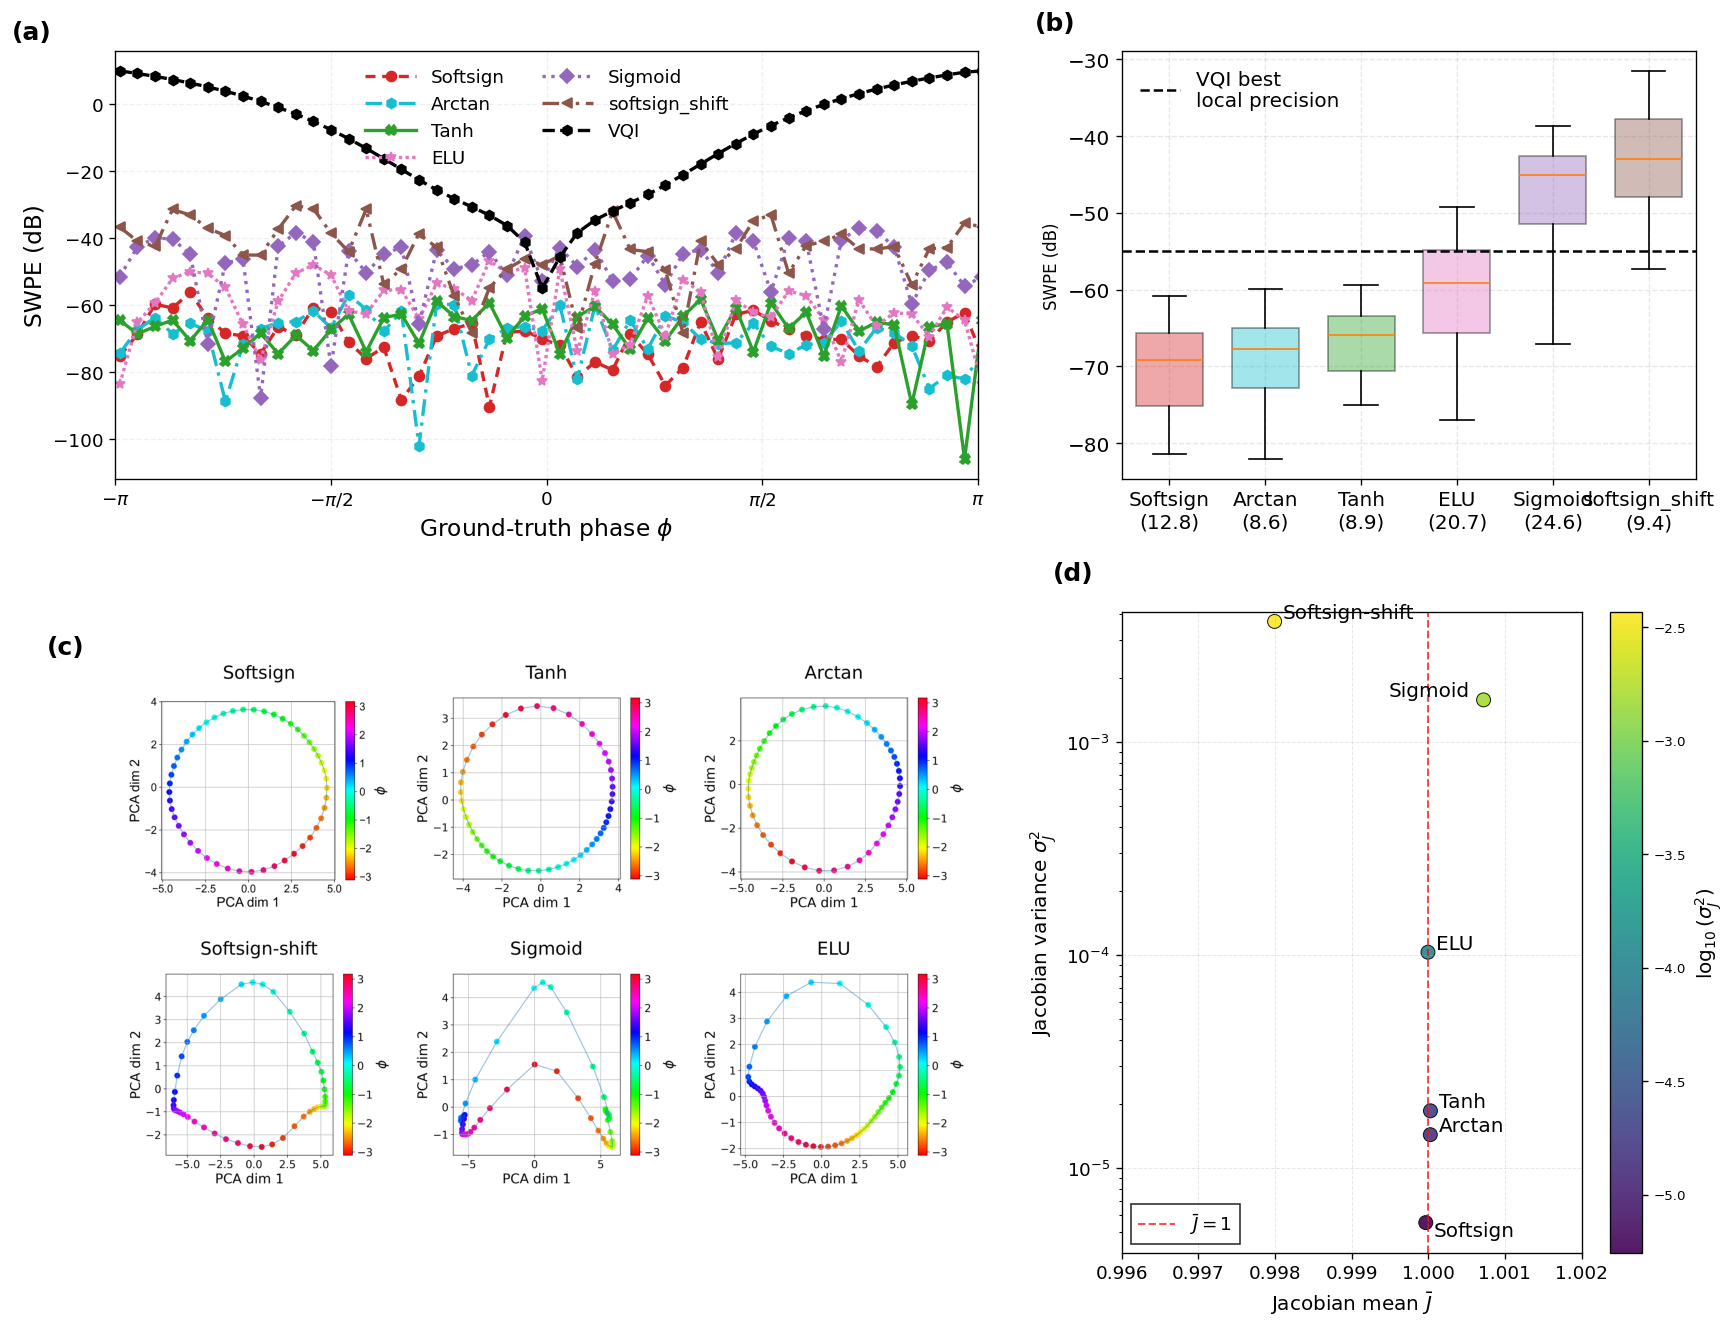

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os
import fitz  # PyMuPDF

# =====================================================
# 全局配置
# =====================================================
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 1.6,
    "figure.dpi": 120
})

# =====================================================
# 参数定义
# =====================================================
n_qubits = 8
n_enc, n_dec = 1, 1
phi_train_samples = 100
n_phi = 50
phi_std = 0.7

phi_trues = np.linspace(-np.pi + np.pi/phi_train_samples, 
                        np.pi + np.pi/phi_train_samples, n_phi)

# =====================================================
# 模型配置
# =====================================================
vqi_path = f"VQI/{n_qubits}/vqc_{n_enc}_{n_dec}_{phi_std}"
vqcnni_base = f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}"

models = {
    "VQI": {"path": vqi_path, "label": "VQI", "color": "black", 
            "marker": "h", "linestyle": "--", "qfi": 17.4},
    "tanh": {"path": f"{vqcnni_base}/tanh", "label": "Tanh", "color": "#2ca02c",
             "marker": "X", "linestyle": "-", "qfi": 8.9},
    "sigmoid": {"path": f"{vqcnni_base}/sigmoid", "label": "Sigmoid", "color": "#9467bd",
                "marker": "D", "linestyle": ":", "qfi": 24.6},
    "softsign": {"path": f"{vqcnni_base}/softsign", "label": "Softsign", "color": "#d62728",
                 "marker": "o", "linestyle": (0, (3, 2)), "qfi": 12.8},
    "softsign_shift": {"path": f"{vqcnni_base}/softsign_shift", "label": "softsign_shift", 
                       "color": "#8c564b", "marker": "<", "linestyle": (0, (5, 2, 1, 2, 1, 2)), "qfi": 9.4},
    "elu": {"path": f"{vqcnni_base}/elu", "label": "ELU", "color": "#e377c2",
            "marker": "*", "linestyle": (0, (1, 1)), "qfi": 20.7},
    "arctan": {"path": f"{vqcnni_base}/arctan", "label": "Arctan", "color": "#17becf",
               "marker": "h", "linestyle": (0, (5, 2, 1, 2)), "qfi": 8.6}
}

# =====================================================
# Jacobian数据
# =====================================================
jacobian_data = {
    'tanh': {'mean': 1.0000294539239016, 'var': 1.8566152934941547e-05},
    'sigmoid': {'mean': 1.000722381941264, 'var': 0.0015767558672795307},
    'elu': {'mean': 0.9999968942878045, 'var': 0.00010310047034810306},
    'arctan': {'mean': 1.00002755806634, 'var': 1.4348247494348468e-05},
    'softsign': {'mean': 0.9999684924136879, 'var': 5.547654738055314e-06},
    'softsign_shift': {'mean': 0.9979963921744658, 'var': 0.003680973121346913}
}

# =====================================================
# 加载并计算SWPE
# =====================================================
def compute_swpe_db(phi_pred, phi_true):
    diff = np.angle(np.exp(1j * (phi_pred - phi_true)))
    return 10 * np.log10(diff**2 + 1e-12)

phi_preds = {}
swpe_data = {}

for name, cfg in models.items():
    file = os.path.join(cfg["path"], "phi_preds.npy")
    if os.path.exists(file):
        phi_preds[name] = np.load(file)
        swpe_data[name] = compute_swpe_db(phi_preds[name], phi_trues)
    else:
        print(f"Warning: {file} not found")

# 按性能排序
sorted_models = sorted([m for m in models.keys() if m in swpe_data], 
                       key=lambda x: np.mean(swpe_data[x]))

# =====================================================
# 创建图形 - 新布局：a(左上，扩大), b(右上，减小), c(左下，扩大), d(右下，减小)
# =====================================================
# 布局：2x2网格，但调整高度和宽度比例
# 高度比例：上行(a和b) : 下行(c和d) = 1.2 : 1.0  (让a和c都较大)
# 宽度比例：左列(a和c) : 右列(b和d) = 1.6 : 0.7  (让a和c更宽，b和d更窄)
fig = plt.figure(figsize=(17, 13))
gs = fig.add_gridspec(2, 2, 
                      height_ratios=[0.8, 1.2],   # 上:下 = 1.2:1.0
                      width_ratios=[1.2, 0.8],    # 左:右 = 1.6:0.7
                      hspace=0.25, wspace=0.2)

ax1 = fig.add_subplot(gs[0, 0])  # (a) SWPE curves - 左上，扩大
ax2 = fig.add_subplot(gs[0, 1])  # (b) Boxplot - 右上，减小
ax3 = fig.add_subplot(gs[1, 0])  # (c) Latent manifold - 左下，扩大
ax4 = fig.add_subplot(gs[1, 1])  # (d) Jacobian plot - 右下，减小

# =====================================================
# (a) SWPE曲线 - 扩大版本
# =====================================================
for name in sorted_models:
    cfg = models[name]
    y = swpe_data[name]
    
    ax1.scatter(phi_trues, y, s=14, alpha=0.08, color=cfg["color"], zorder=1)
    ax1.plot(phi_trues, y, label=cfg["label"], marker=cfg["marker"], 
             linestyle=cfg["linestyle"], color=cfg["color"], markersize=6, linewidth=2.0)

ax1.set_xlabel(r"Ground-truth phase $\phi$", fontsize=14)
ax1.set_ylabel(r"SWPE (dB)", fontsize=14)
ax1.set_xlim(-np.pi, np.pi)
ax1.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax1.set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
ax1.grid(True, linestyle="--", alpha=0.20)
ax1.legend(frameon=False, ncol=2, loc="best", handlelength=2.8, fontsize=11)
ax1.text(-0.12, 1.03, "(a)", transform=ax1.transAxes, fontsize=15, fontweight="bold")

# =====================================================
# (b) Boxplot - 紧凑版本（右上）
# =====================================================
box_data, box_labels, box_colors = [], [], []

for name in sorted_models:
    if name != "VQI":
        box_data.append(swpe_data[name])
        box_labels.append(f"{models[name]['label']}\n({models[name]['qfi']})")
        box_colors.append(models[name]["color"])

# VQI基线
center_idx = np.argmin(np.abs(phi_trues))
vqi_baseline = swpe_data["VQI"][center_idx]

bp = ax2.boxplot(box_data, labels=box_labels, showfliers=False, 
                  patch_artist=True, widths=0.7, whis=(5, 95))

for patch, c in zip(bp["boxes"], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.4)

ax2.axhline(y=vqi_baseline, linestyle="--", linewidth=1.5, color="black", 
            label="VQI best\nlocal precision")
ax2.set_ylabel(r"SWPE (dB)", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.30)
ax2.legend(frameon=False, loc="best", fontsize=12)
ax2.tick_params(axis="x", rotation=0, labelsize=12)
ax2.tick_params(axis="y", labelsize=12)
ax2.text(-0.15, 1.05, "(b)", transform=ax2.transAxes, fontsize=15, fontweight="bold")

# =====================================================
# (c) 潜在流形图 - 大幅扩大（左下）
# =====================================================
pdf_path = "./latent_manifold_all_models.pdf"

if os.path.exists(pdf_path):
    try:
        doc = fitz.open(pdf_path)
        # 大幅提高缩放比例，充分利用扩大后的空间
        pix = doc[0].get_pixmap(matrix=fitz.Matrix(3.8, 3.8), alpha=False)
        img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
        ax3.imshow(img)
        doc.close()
    except Exception as e:
        print(f"Failed to load PDF: {e}")
        ax3.text(0.5, 0.5, "Failed to load PDF", ha="center", va="center", fontsize=12)
else:
    print(f"Warning: {pdf_path} not found")
    ax3.text(0.5, 0.5, "latent_manifold_all_models.pdf not found", ha="center", va="center", fontsize=12)

ax3.axis("off")
ax3.text(-0.08, 1.02, "(c)", transform=ax3.transAxes, fontsize=15, fontweight="bold")

# =====================================================
# (d) Jacobian mean vs variance - 紧凑版本（右下）
# =====================================================
# 准备数据
activations = list(jacobian_data.keys())
jacobian_mean = [jacobian_data[act]['mean'] for act in activations]
jacobian_var = [jacobian_data[act]['var'] for act in activations]

# 基于方差的对数着色
colors_log = np.log10(jacobian_var)
scatter = ax4.scatter(jacobian_mean, jacobian_var, s=70, c=colors_log, 
                      cmap='viridis', edgecolor='black', linewidth=0.6, alpha=0.9)

# 标注点 - 更紧凑
label_names = ['Tanh', 'Sigmoid', 'ELU', 'Arctan', 'Softsign', 'Softsign-shift']
for i, label in enumerate(label_names):
    if label == 'Sigmoid':
        ax4.annotate(label, (jacobian_mean[i], jacobian_var[i]), 
                    xytext=(-8, 2), textcoords='offset points', 
                    fontsize=12, ha='right')
    elif label == 'Softsign':
        ax4.annotate(label, (jacobian_mean[i], jacobian_var[i]), 
                    xytext=(5, -8), textcoords='offset points', 
                    fontsize=12)
    else:
        ax4.annotate(label, (jacobian_mean[i], jacobian_var[i]), 
                    xytext=(5, 2), textcoords='offset points', 
                    fontsize=12)

# 理想线
ax4.axvline(x=1.0, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label=r'$\bar{J}=1$')

# 轴标签
ax4.set_xlabel(r'Jacobian mean $\bar{J}$', fontsize=12)
ax4.set_ylabel(r'Jacobian variance $\sigma_J^2$', fontsize=12)
ax4.set_yscale('log')

# 色标 - 紧凑
cbar = plt.colorbar(scatter, ax=ax4, pad=0.05)
cbar.set_label(r'$\log_{10}(\sigma_J^2)$', fontsize=12)
cbar.ax.tick_params(labelsize=8)

# 网格和图例
ax4.grid(True, alpha=0.3, linestyle='--', linewidth=0.6)
ax4.legend(loc='lower left', frameon=True, fancybox=False, edgecolor='black', fontsize=11)
ax4.text(-0.15, 1.05, "(d)", transform=ax4.transAxes, fontsize=15, fontweight="bold")

# 调整范围让图形更紧凑
x_min, x_max = ax4.get_xlim()
ax4.set_xlim(min(x_min, 0.996), max(x_max, 1.002))

# 调整y轴范围
y_min, y_max = ax4.get_ylim()
ax4.set_ylim(y_min, y_max * 0.8)

# =====================================================
# 保存
# =====================================================
plt.tight_layout()
# plt.savefig("Fig2_main_four_panels.pdf", bbox_inches='tight', dpi=600, format='pdf', pad_inches=0)
# plt.savefig("Fig2_main_four_panels.png", bbox_inches="tight", dpi=300, pad_inches=0)
plt.show()

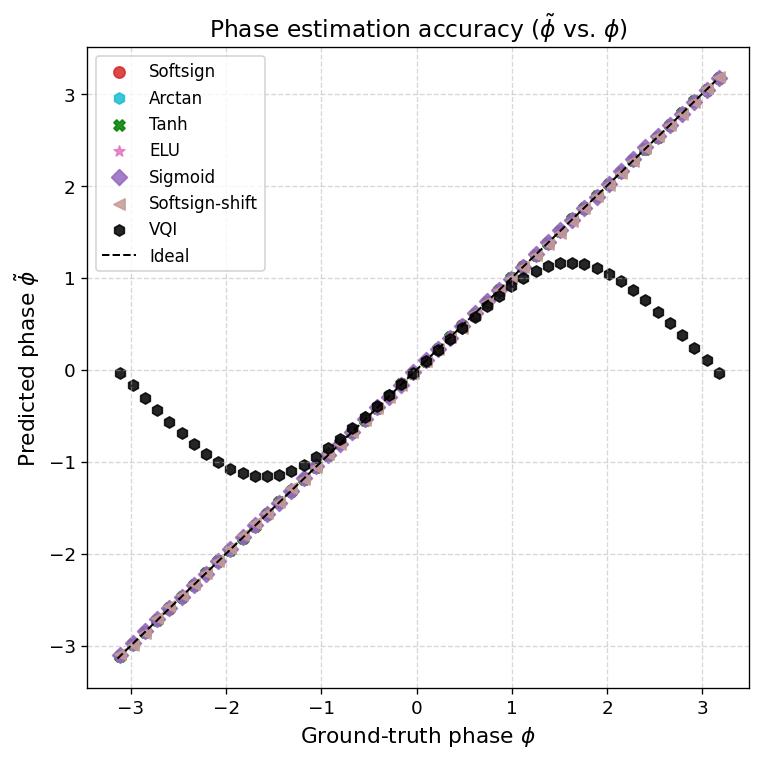

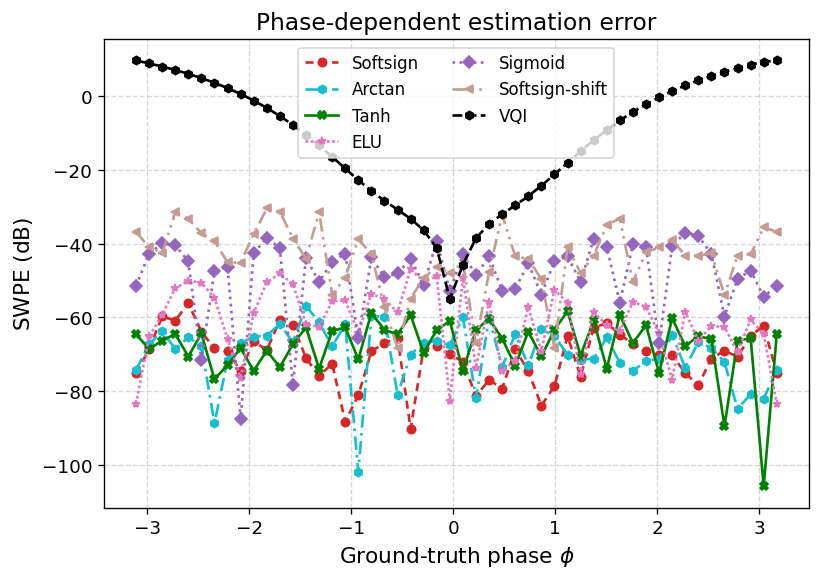


===== Average SWPE (dB) =====
1. Softsign            -70.62 dB  -90.27 dB  -56.21 dB  -69.19 dB
2. Arctan              -69.83 dB  -101.96 dB  -56.85 dB  -67.78 dB
3. Tanh                -67.78 dB  -105.88 dB  -58.29 dB  -65.84 dB
4. ELU                 -61.26 dB  -83.49 dB  -46.85 dB  -59.12 dB
5. Sigmoid             -48.61 dB  -87.62 dB  -36.97 dB  -45.08 dB
6. Softsign-shift      -43.70 dB  -68.34 dB  -30.43 dB  -43.04 dB
7. VQI                 -11.23 dB  -55.00 dB  9.76 dB  -7.14 dB


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 1.6,
    "figure.dpi": 120
})

# ===============================
# parameters
# ===============================
n_qubits = 8
n_enc, n_dec = 1, 1
# phi_trues = np.linspace(-np.pi + np.pi/100, np.pi + np.pi/100, 50)
phi_train_samples = 100
n_phi = 50              # points for QFI/CFI plotting
phi_trues = np.linspace(-np.pi + np.pi/phi_train_samples, np.pi + np.pi/phi_train_samples, n_phi)
phi_std = 0.7
scope = [-np.pi, np.pi]

vqi_path = f"VQI/{n_qubits}/vqc_{n_enc}_{n_dec}_{phi_std}"
vqcnni_base_path = f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}"

paths = {
    "VQI": vqi_path,
    "tanh": f"{vqcnni_base_path}/tanh",
    "sigmoid":  f"{vqcnni_base_path}/sigmoid",
    "softsign": f"{vqcnni_base_path}/softsign",
    "softsign_shift": f"{vqcnni_base_path}/softsign_shift",
    "elu":      f"{vqcnni_base_path}/elu",
    "arctan":   f"{vqcnni_base_path}/arctan",
}

markers = {
    "VQI": "h",
    "tanh": "X",
    "sigmoid": "D",
    "softsign": "o",
    "softsign_shift": "<",   # 对称设计
    "elu": "*",
    "arctan": "h"
}

linestyles = {
    "VQI": "--",
    "tanh": "-",
    "sigmoid": ":",
    "softsign": (0,(3,2)),
    "softsign_shift": (0,(5,2,1,2,1,2)),  # 更复杂 pattern
    "elu": (0,(1,1)),
    "arctan": (0,(5,2,1,2))
}

colors = {
    "VQI": "black",
    "tanh": "green",
    "softplus": "#1f77b4",
    "softsign_shift": "#6baed6",   # 浅蓝
    "sigmoid": "#9467bd",
    "relu": "#ff7f0e",
    "cos": "#2ca02c",
    "softsign": "#d62728",
    "softsign_shift": "#c49c94",   # 浅棕
    "elu": "#e377c2",
    "arctan": "#17becf"
}

label_map = {
    "VQI": "VQI",
    "tanh": "Tanh",
    "sigmoid": "Sigmoid",
    "softsign": "Softsign",
    "softsign_shift": "Softsign-shift",
    "elu": "ELU",
    "arctan": "Arctan"
}

# ===============================
# load data
# ===============================
phi_preds = {}

for name, path in paths.items():
    file = os.path.join(path, "phi_preds.npy")
    if os.path.exists(file):
        phi_preds[name] = np.load(file)
    else:
        print(f"Warning: {file} not found")

# ===============================
# wrapped phase error
# ===============================
def compute_swpe_db(phi_pred, phi_true):

    diff = np.angle(np.exp(1j*(phi_pred - phi_true)))
    swpe = diff**2 + 1e-12

    return 10*np.log10(swpe)


SWPE = {}
mean_swpe = {}
min_swpe = {}
max_swpe = {}
median_swpe = {}

for name in phi_preds:

    SWPE[name] = compute_swpe_db(phi_preds[name], phi_trues)
    mean_swpe[name] = np.mean(SWPE[name])
    median_swpe[name] = np.median(SWPE[name])
    min_swpe[name] = np.min(SWPE[name])
    max_swpe[name] = np.max(SWPE[name])

# ===============================
# sort models by performance
# ===============================
sorted_models = sorted(mean_swpe, key=lambda x: mean_swpe[x])

# =====================================================
# FIGURE 1: Predicted vs True φ
# =====================================================

plt.figure(figsize=(6.5,6.5))

for name in sorted_models:
    label = label_map.get(name, name)
    plt.scatter(
        phi_trues,
        phi_preds[name],
        label=f"{label}",
        marker=markers[name],
        color=colors[name],
        s=45,
        alpha=0.85
    )

lims = [scope[0], scope[1]]

plt.plot(lims, lims, 'k--', linewidth=1.2, label="Ideal")
plt.xlabel(r"Ground-truth phase $\phi$")
plt.ylabel(r"Predicted phase $\tilde{\phi}$")
plt.title(r"Phase estimation accuracy ($\tilde{\phi}$ vs. $\phi$)")

plt.legend(frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("./phase_estimation_scatter.png", dpi=600)

plt.show()


# =====================================================
# FIGURE 2: SWPE vs φ
# =====================================================

plt.figure(figsize=(7,5))

for name in sorted_models:
    label = label_map.get(name, name)
    plt.plot(
        phi_trues,
        SWPE[name],
        label=f"{label}",
        marker=markers[name],
        linestyle=linestyles[name],
        color=colors[name],
        markersize=5
    )

plt.xlabel(r"Ground-truth phase $\phi$")
plt.ylabel(r"$\mathrm{SWPE}$ (dB)")
plt.title(r"Phase-dependent estimation error")

plt.legend(frameon=True, ncol=2)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("./SWPE_all_models.png", dpi=600)

plt.savefig(
    "SWPE_all_models.pdf",
    bbox_inches='tight',
    dpi=600,
    format='pdf'
)

plt.show()


# ===============================
# print ranking
# ===============================

print("\n===== Average SWPE (dB) =====")

for i, name in enumerate(sorted_models):
    label = label_map.get(name, name)
    print(f"{i+1}. {label:18s}  {mean_swpe[name]:.2f} dB  {min_swpe[name]:.2f} dB  {max_swpe[name]:.2f} dB  {median_swpe[name]:.2f} dB")



C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_20248\3831738902.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  QFI[name] = float(qfi)


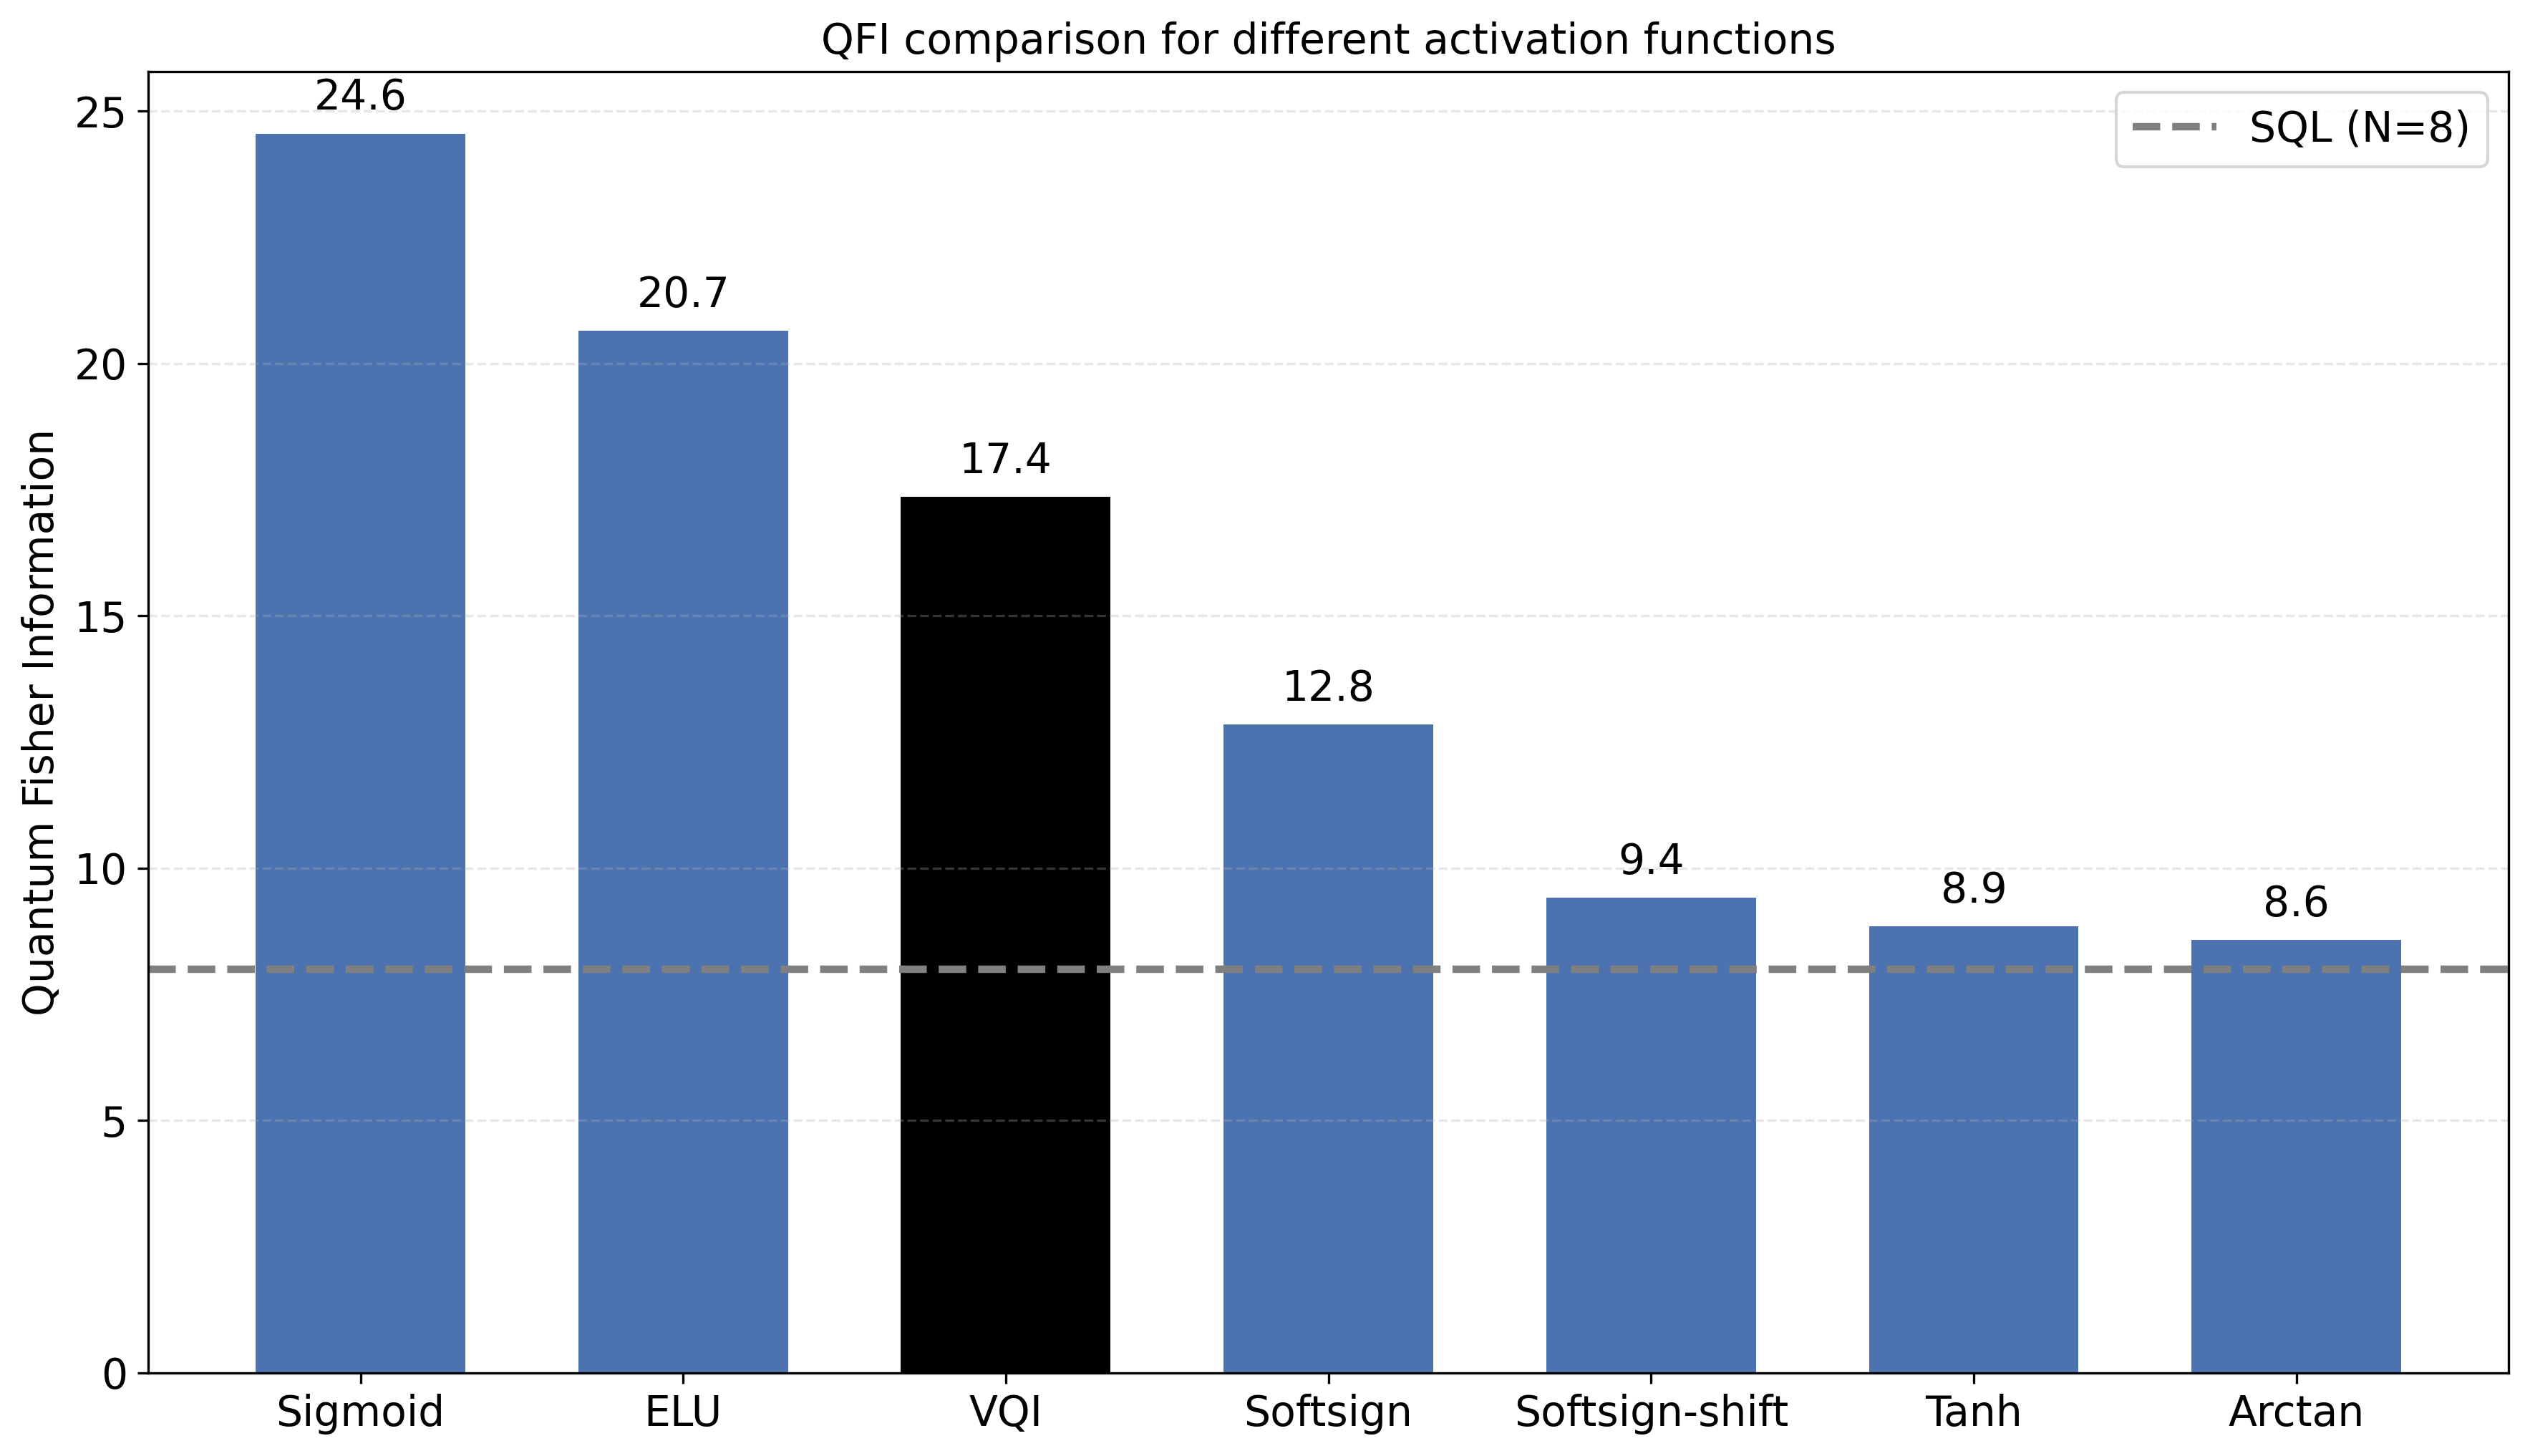

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.dpi": 300
})

# -----------------------
# load QFI
# -----------------------
QFI = {}

for name, path in paths.items():
    file = os.path.join(path, "QFI.npy")
    
    if os.path.exists(file):
        qfi = np.load(file)
        # QFI与phase无关
        QFI[name] = float(qfi)

    else:
        print(f"Warning: {file} not found")

# -----------------------
# sort by QFI
# -----------------------
sorted_models = sorted(QFI, key=QFI.get, reverse=True)

models = sorted_models
values = [QFI[m] for m in models]
labels = [label_map.get(m, m) for m in models]

# ===============================
# plot bar chart
# ===============================
colors = []
for m in models:
    if m == "VQI":
        colors.append("black")
    else:
        colors.append("#4C72B0")
        
plt.figure(figsize=(12,7))

bars = plt.bar(labels, values, color=colors, width=0.65)

# -----------------------
# theoretical limits
# -----------------------
plt.axhline(
    n_qubits,
    linestyle="--",
    color="gray",
    linewidth=2.5,
    label=f"SQL (N={n_qubits})"
)

# -----------------------
# label value on bar
# -----------------------
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=14
    )

# -----------------------
# figure settings
# -----------------------
plt.ylabel("Quantum Fisher Information")
plt.title("QFI comparison for different activation functions")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig("./QFI_bar.png", dpi=300)

plt.show()